# 🤖 NewsBot Intelligence System
## ITAI 2373 - Mid-Term Group Project Template

**Team Members:** Nichelle Graf
**Date:** 4/30/2026
**GitHub Repository:** https://github.com/Nichelleg/ITAI2373-NewsBot-Midterm

---

## 🎯 Project Overview

Welcome to your NewsBot Intelligence System! This notebook will guide you through building a comprehensive NLP system that:

- 📰 **Processes** news articles with advanced text cleaning
- 🏷️ **Classifies** articles into categories (Politics, Sports, Technology, Business, Entertainment, Health)
- 🔍 **Extracts** named entities (people, organizations, locations, dates, money)
- 😊 **Analyzes** sentiment and emotional tone
- 📊 **Generates** insights for business intelligence

### 📚 Module Integration Checklist
- [ ] **Module 1:** NLP applications and real-world context
- [ ] **Module 2:** Text preprocessing pipeline
- [ ] **Module 3:** TF-IDF feature extraction
- [ ] **Module 4:** POS tagging analysis
- [ ] **Module 5:** Syntax parsing and semantic analysis
- [ ] **Module 6:** Sentiment and emotion analysis
- [ ] **Module 7:** Text classification system
- [ ] **Module 8:** Named Entity Recognition

---

## 📦 Setup and Installation

Let's start by installing and importing all the libraries we'll need for our NewsBot system.

In [75]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# You might need to download these the first time
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [76]:
# Install required packages 
!pip install spacy scikit-learn nltk pandas matplotlib seaborn wordcloud plotly
!python -m spacy download en_core_web_sm

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')

print("✅ All packages installed successfully!")

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------------------ --------------------- 5.8/12.8 MB 29.3 MB/s eta 0:00:01
     ------------------------------------- - 12.3/12.8 MB 29.6 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 26.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✅ All packages installed successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\catde\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [77]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tag import pos_tag

# Scikit-learn for machine learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📚 All libraries imported successfully!")
print(f"🔧 spaCy model loaded: {nlp.meta['name']} v{nlp.meta['version']}")

📚 All libraries imported successfully!
🔧 spaCy model loaded: core_web_sm v3.8.0


## 📊 Data Loading and Exploration

### 🎯 Module 1: Understanding Our NLP Application

Before we dive into the technical implementation, let's understand the real-world context of our NewsBot Intelligence System. This system addresses several business needs:

1. **Media Monitoring:** Automatically categorize and track news coverage
2. **Business Intelligence:** Extract key entities and sentiment trends
3. **Content Management:** Organize large volumes of news content
4. **Market Research:** Understand public sentiment about topics and entities

**💡 Discussion Question:** What other real-world applications can you think of for this type of system? Consider different industries and use cases.

Beyond general media monitoring, this NewsBot system has high utility in the Short Term Rental/Hospitality sectors. As an AirBnb Property Care Manager, I could use this NLP pipeline to automatically monitor local news for regulatory changes in short-term rentals or identify sentiment trends regarding tourism in the Houston area. A particular pain point in this business is inventory management. The NewsBot Solution: By processing a diverse world news dataset, this bot acts as an "inventory scout." It identifies supply chain and economic news and signals that allow us to:
- Pre-empt price hikes: buy supplies before inflation hits specific goods.
- Pivot to local Houston vendors when global shipping news looks grim.
- Streamline Planning: Use sentiment analysis to gauge if the travel industry (and therefore our need for inventory) is trending up or down.

In [78]:
import pandas as pd
import json

# Load dataset
with open('News_Category_Dataset_v3.json', 'r') as f:
    data = [json.loads(line) for line in f]

df = pd.DataFrame(data)

# Keep only needed columns
df = df[['category', 'headline', 'short_description']]

# Combine text fields
df['content'] = df['headline'] + " " + df['short_description']

# Map categories to broader groups
category_map = {
    'POLITICS': 'Politics',
    'THE WORLDPOST': 'Politics',
    'BUSINESS': 'Business',
    'SPORTS': 'Sports',
    'ENTERTAINMENT': 'Entertainment',
    'COMEDY': 'Entertainment',
    'MEDIA': 'Entertainment',
    'WELLNESS': 'Health',
    'HEALTHY LIVING': 'Health',
    'SCIENCE': 'Tech',
    'TECH': 'Tech'
}

df['category'] = df['category'].map(category_map)

# Drop rows with missing values AFTER mapping
df_clean = df.dropna(subset=['content', 'category'])

# -------- BALANCING STEP (SAFE VERSION) --------
target_size = 120

dfs = []

for cat in df_clean['category'].unique():
    subset = df_clean[df_clean['category'] == cat]
    sample_size = min(len(subset), target_size)
    dfs.append(subset.sample(n=sample_size, random_state=42))

df_final = pd.concat(dfs)

# Shuffle rows
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# Save dataset
df_final.to_csv("newsbot_dataset.csv", index=False)

# -------- CHECK RESULTS --------
print("Shape:", df_final.shape)
print("\nColumns:", df_final.columns)
print("\nCategory Distribution:\n", df_final['category'].value_counts())

df_final.head()

Shape: (720, 4)

Columns: Index(['category', 'headline', 'short_description', 'content'], dtype='str')

Category Distribution:
 category
Sports           120
Entertainment    120
Tech             120
Politics         120
Business         120
Health           120
Name: count, dtype: int64


,category,headline,short_description,content
0,Sports,PETA Is Not Happy About This Photo Of Dez Brya...,This is serious monkey business.,PETA Is Not Happy About This Photo Of Dez Brya...
1,Sports,Shaq Provides Surprise Backup In Kids' Basketb...,The NBA legend dropped in to the Gainesville P...,Shaq Provides Surprise Backup In Kids' Basketb...
2,Entertainment,"In Real Life, The 'Girls' Would Not Make Rent",,"In Real Life, The 'Girls' Would Not Make Rent"
3,Tech,North Star's Distance To Earth: Polaris Is Not...,Astronomers are lining up behind van Leeuwen. ...,North Star's Distance To Earth: Polaris Is Not...
4,Politics,Democrat Asks Judge To Block Trump Voter Fraud...,He's already suing the panel for access to doc...,Democrat Asks Judge To Block Trump Voter Fraud...


In [79]:
print(df.columns)


Index(['category', 'headline', 'short_description', 'content'], dtype='str')


📊 DATASET OVERVIEW
--------------------------------------------------
Total articles: 720
Unique categories: 6
Date range: Not available in this dataset


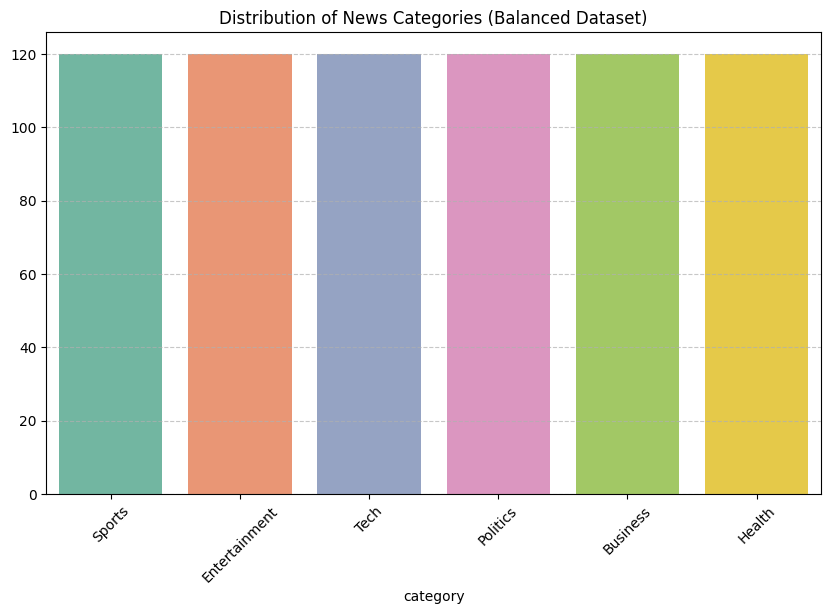


Average article length: 28.36 words


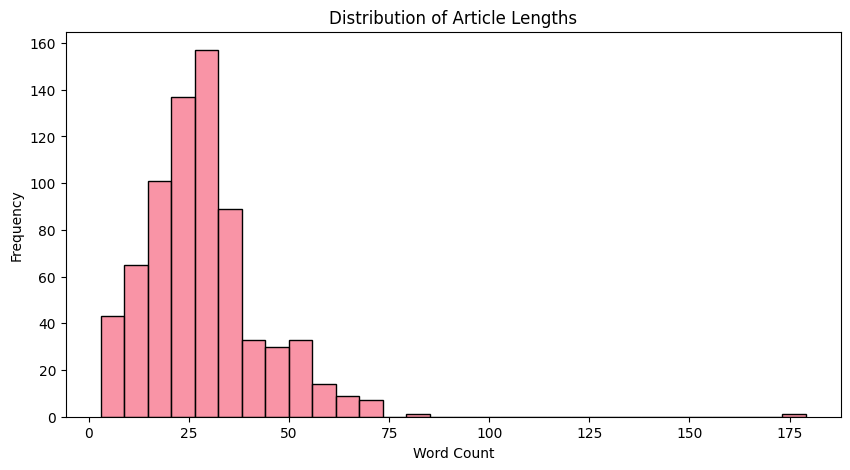

In [80]:
# -------- 1. BASIC DATASET EXPLORATION --------
print("📊 DATASET OVERVIEW")
print("-" * 50)

print(f"Total articles: {len(df_final)}")
print(f"Unique categories: {df_final['category'].nunique()}")
print("Date range: Not available in this dataset")

# -------- 2. VISUALIZE CATEGORY DISTRIBUTION --------
import seaborn as sns
import matplotlib.pyplot as plt

category_counts = df_final['category'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    palette='Set2'
)
plt.title('Distribution of News Categories (Balanced Dataset)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# -------- 3. WORD COUNT ANALYSIS --------
df_final['word_count'] = df_final['content'].apply(lambda x: len(str(x).split()))

print(f"\nAverage article length: {df_final['word_count'].mean():.2f} words")

# Visualize article length distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_final['word_count'], bins=30)
plt.title('Distribution of Article Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

## 🧹 Text Preprocessing Pipeline

### 🎯 Module 2: Advanced Text Preprocessing

Now we'll implement a comprehensive text preprocessing pipeline that cleans and normalizes our news articles. This is crucial for all downstream NLP tasks.

**Key Preprocessing Steps:**
1. **Text Cleaning:** Remove HTML, URLs, special characters
2. **Tokenization:** Split text into individual words
3. **Normalization:** Convert to lowercase, handle contractions
4. **Stop Word Removal:** Remove common words that don't carry meaning
5. **Lemmatization:** Reduce words to their base form

**💡 Think About:** Why is preprocessing so important? What happens if we skip these steps?

Preprocessing is the essential "filter" that transforms raw, noisy text into a structured format the computer can mathematically analyze. Without it, the model is distracted by "noise"—treating "The" and "the" as different entities or becoming overwhelmed by meaningless filler words like "is" and "of." If you skip these steps, the "Garbage In, Garbage Out" rule takes over: the NewsBot would fail to recognize that "robotics," "Robotics," and "robot" all refer to the same core trend, resulting in fragmented data and inaccurate business insights. By cleaning and normalizing the text, you ensure the AI ignores the fluff and focuses exclusively on the high-value "signals" like market shifts or technological innovations that actually impact your bottom line.

In [81]:
# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))
custom_stopwords = {'inc', 'company', 'said', 'llc', 'corp', 'corporation'}
stop_words.update(custom_stopwords)

def clean_text(text):
    """
    Comprehensive text cleaning function
    
    💡 TIP: This function should handle:
    - HTML tags and entities
    - URLs and email addresses
    - Special characters and numbers
    - Extra whitespace
    """
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Implement text cleaning
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Complete preprocessing pipeline
    
    💡 TIP: This function should:
    - Clean the text
    - Tokenize into words
    - Remove stop words (optional)
    - Lemmatize words (optional)
    - Return processed text
    """
    # Clean text
    text = clean_text(text)
    
    if not text:
        return ""
    
    # Implement tokenization and preprocessing
    # Tokenize
    tokens = [token.lower() for token in word_tokenize(text)]
    
    # Remove stop words if requested
    if remove_stopwords:
        tokens = [token for token in tokens if token.isalpha() and token not in stop_words]

    # Lemmatize if requested
    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Filter out very short words
    tokens = [token for token in tokens if len(token) > 2]
    
    return ' '.join(tokens)

# Test the preprocessing function
sample_text = "Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews"
print("Original text:")
print(sample_text)
print("\nCleaned text:")
print(clean_text(sample_text))
print("\nFully preprocessed text:")
print(preprocess_text(sample_text))

# Apply preprocessing to the actual NewsBot dataset
df_final['processed_content'] = df_final['content'].apply(
    lambda x: preprocess_text(x, remove_stopwords=True, lemmatize=True)
)

# Compare original vs processed text
df_final[['content', 'processed_content']].head()

Original text:
Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews

Cleaned text:
apple inc announced record quarterly earnings today visit for more info technews

Fully preprocessed text:
apple announced record quarterly earnings today visit info technews


,content,processed_content
0,PETA Is Not Happy About This Photo Of Dez Brya...,peta happy photo dez bryant baby monkey seriou...
1,Shaq Provides Surprise Backup In Kids' Basketb...,shaq provides surprise backup kid basketball g...
2,"In Real Life, The 'Girls' Would Not Make Rent",real life girl would make rent
3,North Star's Distance To Earth: Polaris Is Not...,north star distance earth polaris close new st...
4,Democrat Asks Judge To Block Trump Voter Fraud...,democrat asks judge block trump voter fraud pr...


In [82]:
# Apply preprocessing to the dataset
print("🧹 Preprocessing all articles...")

# Create new columns for cleaned and processed text
df_final['headline_clean'] = df_final['headline'].apply(clean_text)
df_final['content_clean'] = df_final['content'].apply(clean_text)

df_final['headline_processed'] = df_final['headline'].apply(preprocess_text)
df_final['content_processed'] = df_final['content'].apply(preprocess_text)

# Combine headline and content for full article analysis
df_final['full_text'] = df_final['headline'] + " " + df_final['content']
df_final['full_text_processed'] = df_final['full_text'].apply(preprocess_text)

print("✅ Preprocessing complete!")

# Show before and after examples
print("\n🔎 BEFORE AND AFTER EXAMPLES")
print("=" * 60)

for i in range(min(3, len(df_final))):
    print(f"\nExample {i+1}:")
    print(f"Original: {df_final.iloc[i]['full_text'][:150]}...")
    print(f"Processed: {df_final.iloc[i]['full_text_processed'][:150]}...")

# Quick check
df_final[['category', 'headline', 'content', 'full_text_processed']].head()

🧹 Preprocessing all articles...
✅ Preprocessing complete!

🔎 BEFORE AND AFTER EXAMPLES

Example 1:
Original: PETA Is Not Happy About This Photo Of Dez Bryant With A Baby Monkey PETA Is Not Happy About This Photo Of Dez Bryant With A Baby Monkey This is seriou...
Processed: peta happy photo dez bryant baby monkey peta happy photo dez bryant baby monkey serious monkey business...

Example 2:
Original: Shaq Provides Surprise Backup In Kids' Basketball Game With Police Shaq Provides Surprise Backup In Kids' Basketball Game With Police The NBA legend d...
Processed: shaq provides surprise backup kid basketball game police shaq provides surprise backup kid basketball game police nba legend dropped gainesville polic...

Example 3:
Original: In Real Life, The 'Girls' Would Not Make Rent In Real Life, The 'Girls' Would Not Make Rent ...
Processed: real life girl would make rent real life girl would make rent...


,category,headline,content,full_text_processed
0,Sports,PETA Is Not Happy About This Photo Of Dez Brya...,PETA Is Not Happy About This Photo Of Dez Brya...,peta happy photo dez bryant baby monkey peta h...
1,Sports,Shaq Provides Surprise Backup In Kids' Basketb...,Shaq Provides Surprise Backup In Kids' Basketb...,shaq provides surprise backup kid basketball g...
2,Entertainment,"In Real Life, The 'Girls' Would Not Make Rent","In Real Life, The 'Girls' Would Not Make Rent",real life girl would make rent real life girl ...
3,Tech,North Star's Distance To Earth: Polaris Is Not...,North Star's Distance To Earth: Polaris Is Not...,north star distance earth polaris close new st...
4,Politics,Democrat Asks Judge To Block Trump Voter Fraud...,Democrat Asks Judge To Block Trump Voter Fraud...,democrat asks judge block trump voter fraud pr...


## 📊 Feature Extraction and Statistical Analysis

### 🎯 Module 3: TF-IDF Analysis

Now we'll extract numerical features from our text using TF-IDF (Term Frequency-Inverse Document Frequency). This technique helps us identify the most important words in each document and across the entire corpus.

**TF-IDF Key Concepts:**
- **Term Frequency (TF):** How often a word appears in a document
- **Inverse Document Frequency (IDF):** How rare a word is across all documents
- **TF-IDF Score:** TF × IDF - balances frequency with uniqueness

**💡 Business Value:** TF-IDF helps us identify the most distinctive and important terms for each news category.

In [83]:
# Create TF-IDF vectorizer
# 💡 TIP: Experiment with different parameters:
# - max_features: limit vocabulary size
# - ngram_range: include phrases (1,1) for words, (1,2) for words+bigrams
# - min_df: ignore terms that appear in less than min_df documents
# - max_df: ignore terms that appear in more than max_df fraction of documents

tfidf_vectorizer = TfidfVectorizer(
    max_features=2000,  # Limit vocabulary for computational efficiency
    ngram_range=(1, 2),  # Include unigrams and bigrams
    min_df=2,  # Ignore terms that appear in less than 2 documents
    max_df=0.8  # Ignore terms that appear in more than 80% of documents
)

# Fit and transform the processed text
print("🔢 Creating TF-IDF features...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df_final['full_text_processed'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"✅ TF-IDF matrix created!")
print(f"📊 Shape: {tfidf_matrix.shape}")
print(f"📝 Vocabulary size: {len(feature_names)}")
print(f"🔢 Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

# Convert to DataFrame for easier analysis
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df['category'] = df_final['category'].values

print("\n🔍 Sample TF-IDF features:")
print(tfidf_df.iloc[:3, :10])  # Show first 3 rows and 10 features

🔢 Creating TF-IDF features...
✅ TF-IDF matrix created!
📊 Shape: (720, 1975)
📝 Vocabulary size: 1975
🔢 Sparsity: 99.40%

🔍 Sample TF-IDF features:
   ability  able  absence  absolutely  absurd  abuse  abused  acceptance  \
0      0.0   0.0      0.0         0.0     0.0    0.0     0.0         0.0   
1      0.0   0.0      0.0         0.0     0.0    0.0     0.0         0.0   
2      0.0   0.0      0.0         0.0     0.0    0.0     0.0         0.0   

   access  according  
0     0.0        0.0  
1     0.0        0.0  
2     0.0        0.0  


In [84]:
# Analyze most important terms per category
def get_top_tfidf_terms(category, n_terms=10):
    """
    Get top TF-IDF terms for a specific category
    
    💡 TIP: This function should:
    - Filter data for the specific category
    - Calculate mean TF-IDF scores for each term
    - Return top N terms with highest scores
    """
    # 🚀 YOUR CODE HERE: Implement category-specific TF-IDF analysis
    category_data = tfidf_df[tfidf_df['category'] == category]
    
    # Calculate mean TF-IDF scores for this category (excluding the category column)
    mean_scores = category_data.drop('category', axis=1).mean().sort_values(ascending=False)
    
    return mean_scores.head(n_terms)

# Analyze top terms for each category
print("🏷️ TOP TF-IDF TERMS BY CATEGORY")
print("=" * 50)

categories = df_final['category'].unique()
category_terms = {}

for category in categories:
    top_terms = get_top_tfidf_terms(category, n_terms=10)
    category_terms[category] = top_terms
    
    print(f"\n📰 {category.upper()}:")
    for term, score in top_terms.items():
        print(f"  {term}: {score:.4f}")

# 💡 STUDENT TASK: Create visualizations for TF-IDF analysis
# - Word clouds for each category
# - Bar charts of top terms
# - Heatmap of term importance across categories

🏷️ TOP TF-IDF TERMS BY CATEGORY

📰 SPORTS:
  player: 0.0328
  team: 0.0298
  nfl: 0.0278
  watch: 0.0260
  fan: 0.0248
  game: 0.0238
  football: 0.0213
  nba: 0.0209
  sport: 0.0179
  first: 0.0171

📰 ENTERTAINMENT:
  trump: 0.0285
  say: 0.0273
  star: 0.0258
  film: 0.0223
  new: 0.0193
  donald trump: 0.0176
  donald: 0.0176
  video: 0.0172
  one: 0.0159
  jimmy: 0.0154

📰 TECH:
  facebook: 0.0326
  apple: 0.0292
  scientist: 0.0259
  video: 0.0214
  get: 0.0210
  new: 0.0193
  tech: 0.0184
  show: 0.0170
  study: 0.0158
  google: 0.0152

📰 POLITICS:
  trump: 0.0872
  donald: 0.0363
  donald trump: 0.0363
  president: 0.0320
  democrat: 0.0192
  republican: 0.0177
  campaign: 0.0174
  american: 0.0171
  huffpost: 0.0164
  plan: 0.0163

📰 BUSINESS:
  job: 0.0316
  bank: 0.0263
  business: 0.0254
  billion: 0.0220
  woman: 0.0184
  year: 0.0181
  customer: 0.0180
  way: 0.0169
  market: 0.0164
  amazon: 0.0164

📰 HEALTH:
  life: 0.0310
  love: 0.0303
  way: 0.0229
  step: 0.0213
  ne

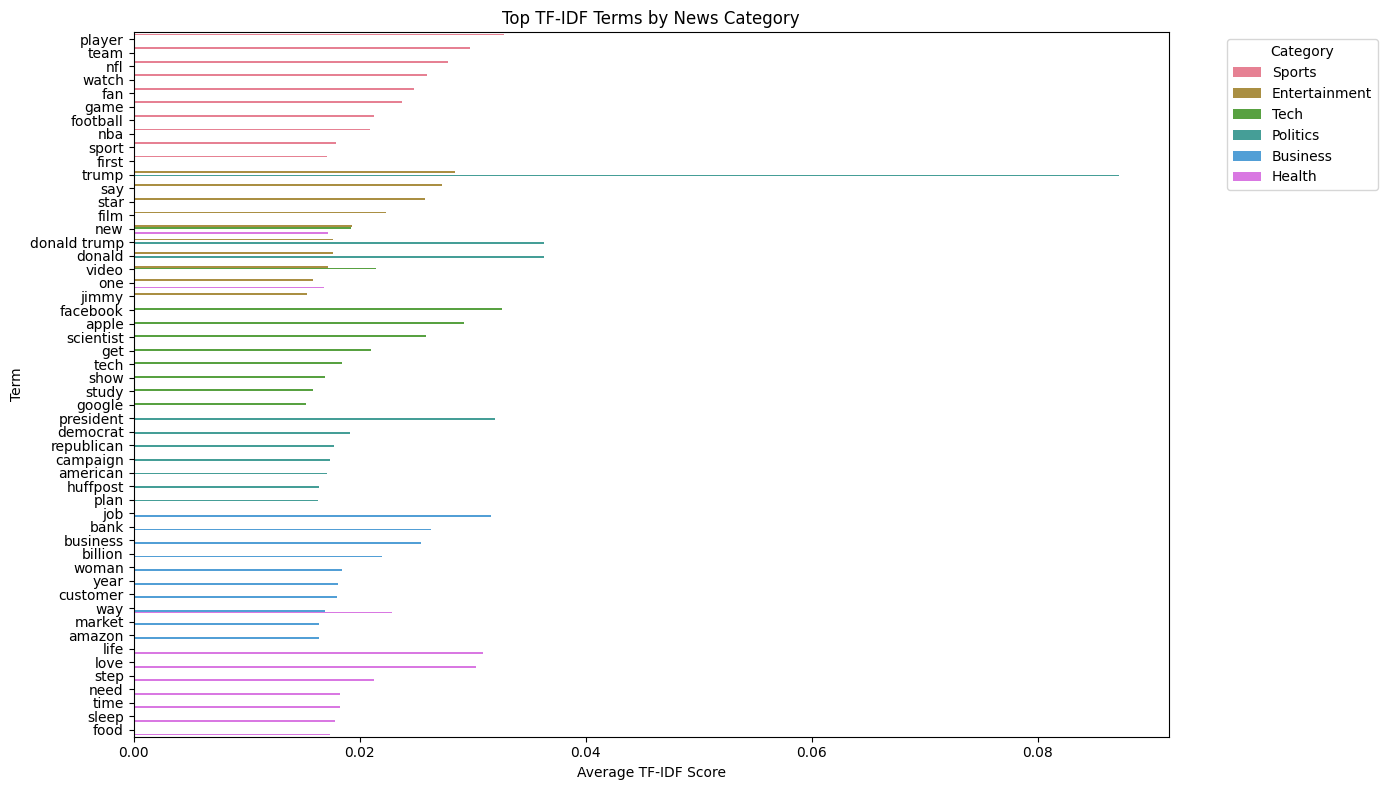

In [85]:
# -------- TF-IDF VISUALIZATION: TOP TERMS BY CATEGORY --------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert category_terms dictionary into a DataFrame
top_terms_data = []

for category, terms in category_terms.items():
    for term, score in terms.items():
        top_terms_data.append({
            'category': category,
            'term': term,
            'score': score
        })

top_terms_df = pd.DataFrame(top_terms_data)

# Plot top terms by category
plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_terms_df,
    x='score',
    y='term',
    hue='category'
)

plt.title('Top TF-IDF Terms by News Category')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Term')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

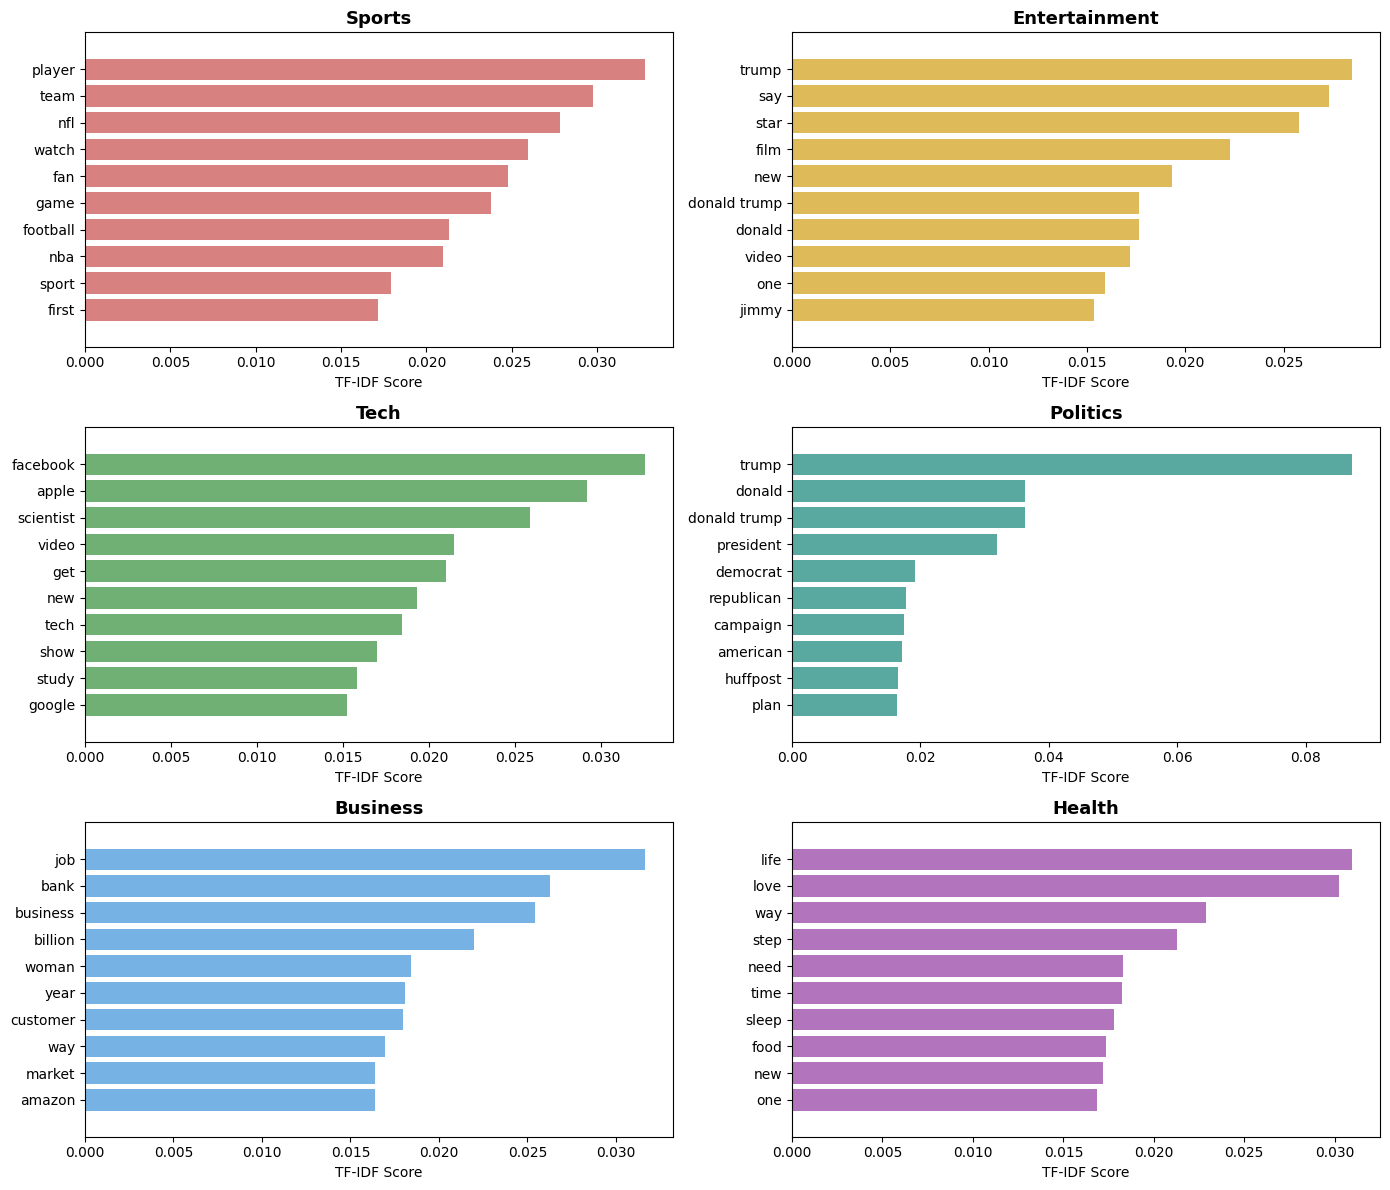

In [86]:
# -------- GRID VISUAL: TOP TF-IDF TERMS BY CATEGORY --------

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

category_colors = {
    'Sports': '#e57373',
    'Entertainment': '#f4c542',
    'Tech': '#66bb6a',
    'Politics': '#4db6ac',
    'Business': '#64b5f6',
    'Health': '#ba68c8'
}

for i, (category, terms) in enumerate(category_terms.items()):
    ax = axes[i]

    # Sort terms highest first
    terms = terms.sort_values(ascending=False)
    ax.invert_yaxis()

    sns.barplot(
        x=terms.values,
        y=terms.index,
        ax=ax,
        color=category_colors.get(category, 'gray')
    )

    ax.margins(y=0.1)
    
    ax.set_title(category, fontsize=13, fontweight='bold')
    ax.set_xlabel("TF-IDF Score")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

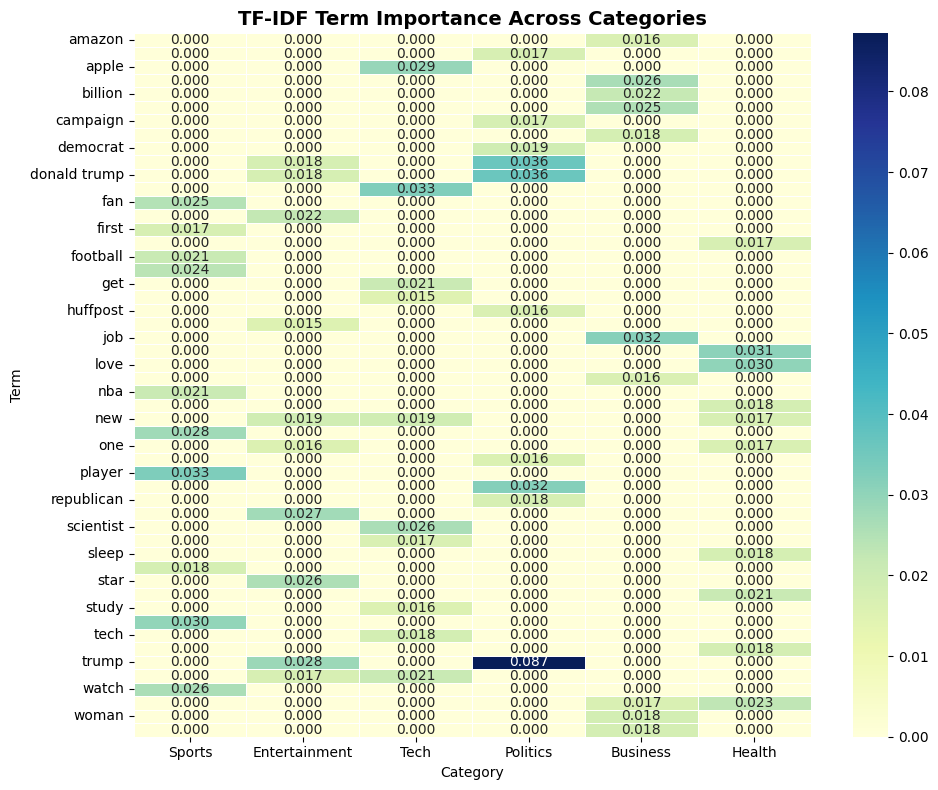

In [87]:
# -------- HEATMAP: TERM IMPORTANCE ACROSS CATEGORIES --------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine top terms into a single DataFrame
heatmap_data = pd.DataFrame(category_terms)

# Fill missing values with 0 (terms not present in a category)
heatmap_data = heatmap_data.fillna(0)

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    linewidths=0.5
)

plt.title("TF-IDF Term Importance Across Categories", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

## 🏷️ Part-of-Speech Analysis

### 🎯 Module 4: Grammatical Pattern Analysis

Let's analyze the grammatical patterns in different news categories using Part-of-Speech (POS) tagging. This can reveal interesting differences in writing styles between categories.

**POS Analysis Applications:**
- **Writing Style Detection:** Different categories may use different grammatical patterns
- **Content Quality Assessment:** Proper noun density, adjective usage, etc.
- **Feature Engineering:** POS tags can be features for classification

**💡 Hypothesis:** Sports articles might have more action verbs, while business articles might have more numbers and proper nouns.

In [88]:
# Analyze POS patterns in text
def analyze_pos_patterns(text):
    if not text or pd.isna(text):
        return {}

    tokens = word_tokenize(str(text))
    pos_tags = pos_tag(tokens)

    pos_counts = Counter([
    tag for word, tag in pos_tags if tag.isalpha()
])
    total_words = sum(pos_counts.values())

    if total_words == 0:
        return {}

    pos_proportions = {
        pos: count / total_words for pos, count in pos_counts.items()
    }

    return pos_proportions


# Analyze POS for each article
pos_results = []

for idx, row in df_final.iterrows():
    pos_analysis = analyze_pos_patterns(row['content'])

    pos_analysis['category'] = row['category']
    pos_analysis['article_id'] = idx

    pos_results.append(pos_analysis)

# Convert results to DataFrame
pos_df = pd.DataFrame(pos_results).fillna(0)

print("✅ POS analysis complete!")
print("Shape:", pos_df.shape)
pos_df.head()

✅ POS analysis complete!
Shape: (720, 34)


,NNP,VBZ,RB,JJ,IN,DT,NN,category,article_id,POS,...,WP,JJS,CD,RBR,JJR,PDT,RBS,EX,FW,UH
0,0.368421,0.105263,0.052632,0.105263,0.157895,0.105263,0.105263,Sports,0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.413793,0.000000,0.000000,0.068966,0.172414,0.103448,0.103448,Sports,1,0.034483,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.300000,0.000000,0.100000,0.000000,0.100000,0.100000,0.100000,Entertainment,2,0.100000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.236842,0.078947,0.105263,0.052632,0.078947,0.026316,0.078947,Tech,3,0.026316,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.387097,0.032258,0.032258,0.000000,0.096774,0.064516,0.096774,Politics,4,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


📊 POS PATTERNS BY CATEGORY

🎯 Key POS patterns by category:
                   NN     NNS     NNP    NNPS      VB     VBD     VBG     VBN  \
category                                                                        
Business       0.1075  0.0522  0.2337  0.0077  0.0382  0.0210  0.0285  0.0126   
Entertainment  0.0855  0.0238  0.3596  0.0039  0.0235  0.0196  0.0162  0.0090   
Health         0.1201  0.0503  0.1498  0.0036  0.0606  0.0135  0.0298  0.0131   
Politics       0.1040  0.0385  0.3359  0.0105  0.0288  0.0206  0.0236  0.0125   
Sports         0.0927  0.0306  0.3990  0.0046  0.0246  0.0233  0.0175  0.0130   
Tech           0.0869  0.0569  0.3266  0.0044  0.0302  0.0144  0.0178  0.0155   

                  VBP     VBZ      JJ     JJR     JJS      RB     RBR     RBS  \
category                                                                        
Business       0.0265  0.0274  0.0552  0.0053  0.0036  0.0369  0.0007  0.0007   
Entertainment  0.0158  0.0389  0.0494  0.0048  0

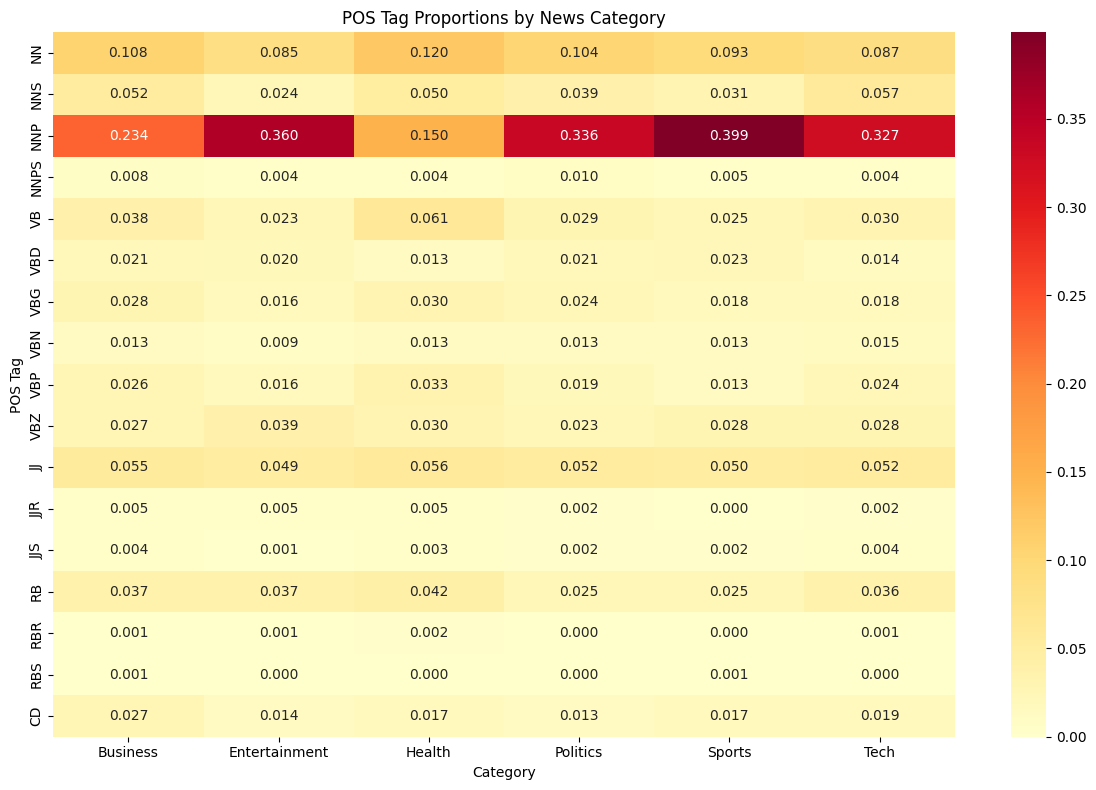


💡 ANALYSIS QUESTIONS:
1. Which category has the highest proportion of proper nouns (NNP/NNPS)?
2. Which category uses the most action verbs (VB, VBD, VBG)?
3. Are there interesting patterns in adjective (JJ) usage?
4. How does number (CD) usage vary across categories?


In [89]:
# Analyze POS patterns by category
print("📊 POS PATTERNS BY CATEGORY")
print("=" * 50)

# Group by category and calculate mean proportions
pos_by_category = pos_df.groupby('category').mean()

# Focus on major POS categories
major_pos = ['NN', 'NNS', 'NNP', 'NNPS', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 
             'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS', 'CD']

# Filter to only include major POS tags that exist in our data
available_pos = [pos for pos in major_pos if pos in pos_by_category.columns]

if available_pos:
    pos_summary = pos_by_category[available_pos]
    
    print("\n🎯 Key POS patterns by category:")
    print(pos_summary.round(4))
    
    # Create visualization
    plt.figure(figsize=(12, 8))
    sns.heatmap(pos_summary.T, annot=True, cmap='YlOrRd', fmt='.3f')
    plt.title('POS Tag Proportions by News Category')
    plt.xlabel('Category')
    plt.ylabel('POS Tag')
    plt.tight_layout()
    plt.show()
    
    # 💡 STUDENT TASK: Analyze the patterns
    # - Which categories use more nouns vs verbs?
    # - Do business articles have more numbers (CD)?
    # - Are there differences in adjective usage?
    
    print("\n💡 ANALYSIS QUESTIONS:")
    print("1. Which category has the highest proportion of proper nouns (NNP/NNPS)?")
    print("2. Which category uses the most action verbs (VB, VBD, VBG)?")
    print("3. Are there interesting patterns in adjective (JJ) usage?")
    print("4. How does number (CD) usage vary across categories?")
else:
    print("⚠️ No major POS tags found in the analysis. Check your POS tagging implementation.")


1. Which category has the highest proportion of proper nouns (NNP/NNPS)?

Answer:
  Sports has the highest proper noun usage (~0.399), followed closely by Entertainment (~0.360) and Politics (~0.336).

Interpretation:
 -Sports articles heavily reference specific people, teams, and organizations (players, NFL teams, etc.)
 -This makes sense because sports reporting is entity-driven
 -Entertainment and Politics also rely on named individuals, but slightly less intensely.



2. Which category uses the most action verbs (VB, VBD, VBG)?

Answer:
 Health (~0.061 VB) shows the highest action verb usage.

Interpretation:
Health writing often includes instructions, processes, and recommendations
  -“eat”, “sleep”, “exercise”, “improve”
This leads to more verb-heavy language

Compare to:
 -Business/Politics → more descriptive and noun-heavy
 -Health → more action-oriented


3. Are there interesting patterns in adjective (JJ) usage?

Answer:
Adjective usage is fairly consistent (~0.049–0.056), but slightly higher in:
 -Health (~0.056)
 -Business (~0.055)

Interpretation:
 -Health uses adjectives to describe conditions and states (“healthy”, “mental”, “physical”)
 -Business uses them for qualitative descriptions (“financial”, “economic”, “global”)

Key insight:
 -Adjectives aren’t the differentiator across categories
 -They’re supporting language, not defining language


4. How does number (CD) usage vary across categories?

Answer:
Business (~0.027) has the highest number usage.

Interpretation:
 -Business articles rely heavily on:
   -financial figures
   -percentages
   -market data
 -Other categories use numbers less frequently because they are more narrative-based

Real-world insight:
 -Business = data-driven language
 -Others = event-driven or descriptive language


These results show that different domains have distinct linguistic signatures:
 -Sports / Politics / Entertainment -> Entity-heavy (proper nouns)
 -Health -> Action-heavy (verbs)
 -Business -> Data-heavy (numbers)

 ---

## 🌳 Syntax Parsing and Semantic Analysis

### 🎯 Module 5: Understanding Sentence Structure

Now we'll use spaCy to perform dependency parsing and extract semantic relationships from our news articles. This helps us understand not just what words are present, but how they relate to each other.

**Dependency Parsing Applications:**
- **Relationship Extraction:** Find connections between entities
- **Event Detection:** Identify who did what to whom
- **Information Extraction:** Extract structured facts from unstructured text

**💡 Business Value:** Understanding sentence structure helps extract more precise information about events, relationships, and actions mentioned in news articles.

In [90]:
# ---------------------------------------------
# Syntactic Feature Extraction using spaCy
# ---------------------------------------------
# This module extracts sentence-level grammatical structure using dependency parsing.
# The goal is to capture how entities and actions relate within each article,
# enabling downstream analysis of linguistic patterns across categories.

from collections import Counter

def extract_syntactic_features(text):
    """
    Extract syntactic features from text using spaCy dependency parsing.

    Returns:
        dict: A structured representation of syntactic characteristics including:
              - Sentence and token counts
              - Dependency label distribution
              - Noun phrase extraction
              - Identified subjects and objects
    """

    # Handle missing or invalid input
    if not text or pd.isna(text):
        return {}

    # Process text through spaCy pipeline
    doc = nlp(str(text))

    # Initialize feature container
    features = {
        'num_sentences': len(list(doc.sents)),
        'num_tokens': len(doc),
        'noun_phrases': [],
        'subjects': [],
        'objects': [],
        'dependency_counts': {}
    }

    # ---------------------------------------------
    # Extract noun phrases (entity/group references)
    # ---------------------------------------------
    features['noun_phrases'] = [
        chunk.text.lower() for chunk in doc.noun_chunks
    ]

    # ---------------------------------------------
    # Identify grammatical subjects and objects
    # ---------------------------------------------
    for token in doc:
        if token.dep_ in ['nsubj', 'nsubjpass']:
            features['subjects'].append(token.text.lower())
        elif token.dep_ in ['dobj', 'iobj', 'pobj']:
            features['objects'].append(token.text.lower())

    # ---------------------------------------------
    # Quantify dependency structure
    # ---------------------------------------------
    # Counts frequency of syntactic roles (e.g., subject, object, modifier)
    dep_counts = Counter(
        token.dep_ for token in doc
        if not token.is_space and not token.is_punct
    )

    features['dependency_counts'] = dict(dep_counts)

    return features


# ---------------------------------------------
# Apply Syntactic Analysis to Sample Articles
# ---------------------------------------------
# A subset of the dataset is used to limit computation time during development.

print("🌳 Performing syntactic analysis...\n")

syntactic_results = []

for idx, row in df_final.head(5).iterrows():
    result = extract_syntactic_features(row['content'])

    # Attach metadata for traceability
    result['category'] = row['category']
    result['article_id'] = idx

    syntactic_results.append(result)


# ---------------------------------------------
# Display Results
# ---------------------------------------------
# Output key structural features for inspection and validation.

for i, result in enumerate(syntactic_results):
    print(f"📄 Article {i+1} ({result['category']}):")
    print(f"  Sentences: {result['num_sentences']}")
    print(f"  Tokens: {result['num_tokens']}")
    print(f"  Noun phrases (sample): {result['noun_phrases'][:3]}")
    print(f"  Subjects (sample): {result['subjects'][:3]}")
    print(f"  Objects (sample): {result['objects'][:3]}\n")

🌳 Performing syntactic analysis...

📄 Article 1 (Sports):
  Sentences: 2
  Tokens: 20
  Noun phrases (sample): ['peta', 'this photo', 'dez bryant']
  Subjects (sample): ['peta', 'this']
  Objects (sample): ['photo', 'bryant', 'monkey']

📄 Article 2 (Sports):
  Sentences: 1
  Tokens: 30
  Noun phrases (sample): ['shaq', 'surprise backup', "kids' basketball game"]
  Subjects (sample): ['shaq', 'legend']
  Objects (sample): ['backup', 'game', 'police']

📄 Article 3 (Entertainment):
  Sentences: 1
  Tokens: 12
  Noun phrases (sample): ['real life', "the 'girls", 'rent']
  Subjects (sample): ['girls']
  Objects (sample): ['life', 'rent']

📄 Article 4 (Tech):
  Sentences: 2
  Tokens: 43
  Noun phrases (sample): ['earth', 'polaris', 'new study']
  Subjects (sample): ['polaris', 'study', 'astronomers']
  Objects (sample): ['earth', 'leeuwen', 'turner']

📄 Article 5 (Politics):
  Sentences: 3
  Tokens: 32
  Noun phrases (sample): ['democrat', 'judge', 'block trump voter fraud probe']
  Subjects

In [91]:
# Visualize dependency parsing for a sample sentence
from spacy import displacy

# Select a representative sample from the processed dataset for dependency parsing visualization.
sample_sentence = df_final.iloc[0]['content']  # First article's content
print(f"📝 Sample sentence: {sample_sentence}")

# Process with spaCy
doc = nlp(sample_sentence)

# Render dependency parse tree using spaCy's displaCy 
print("\n🌳 Dependency Parse Visualization:")
try:
    # This will create an interactive visualization in Jupyter
    displacy.render(doc, style="dep", jupyter=True)
except:
    # Fallback: print dependency information
    print("\n🔗 Dependency Relations:")
    for token in doc:
        if not token.is_space and not token.is_punct:
            print(f"  {token.text} --> {token.dep_} --> {token.head.text}")

# --------------------------------------------------
# Extended Syntactic Analysis: Category-Level Insights
# --------------------------------------------------
# This section outlines potential analytical extensions using syntactic features
# extracted via dependency parsing. These enhancements move beyond visualization
# and toward structured linguistic analysis that can support downstream tasks
# such as classification, pattern recognition, and semantic interpretation.

# Key analytical directions:
# - Compare syntactic complexity across categories (e.g., sentence length, structure)
# - Identify subject–verb–object patterns to understand "who did what"
# - Analyze the distribution of dependency relations within each category
# - Extract features that can be used in machine learning models for classification

📝 Sample sentence: PETA Is Not Happy About This Photo Of Dez Bryant With A Baby Monkey This is serious monkey business.

🌳 Dependency Parse Visualization:


## 😊 Sentiment and Emotion Analysis

### 🎯 Module 6: Understanding Emotional Tone

Let's analyze the sentiment and emotional tone of our news articles. This can reveal interesting patterns about how different types of news are presented and perceived.

**Sentiment Analysis Applications:**
- **Media Bias Detection:** Identify emotional slant in news coverage
- **Public Opinion Tracking:** Monitor sentiment trends over time
- **Content Recommendation:** Suggest articles based on emotional tone

**💡 Hypothesis:** Different news categories might have different emotional profiles - sports might be more positive, politics more negative, etc.

In [92]:
# --------------------------------------------------
# Sentiment Analysis Using VADER (NLTK)
# --------------------------------------------------
# This section evaluates the emotional tone of news articles using the VADER
# sentiment analysis model. VADER is well-suited for short-form text and
# provides a normalized "compound" score representing overall sentiment.

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

# Ensure required resources are available
nltk.download('vader_lexicon', quiet=True)

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()


def analyze_sentiment(text):
    """
    Compute sentiment scores for a given text using VADER.

    Parameters:
        text (str): Input text (e.g., article title + content)

    Returns:
        dict: Dictionary containing:
            - compound (float): Overall sentiment score [-1, 1]
            - sentiment_label (str): Categorized sentiment (positive, neutral, negative)
    """
    if not text or pd.isna(text):
        return {'compound': 0, 'sentiment_label': 'neutral'}

    scores = sia.polarity_scores(str(text))

    # Assign categorical label based on compound score thresholds
    if scores['compound'] >= 0.05:
        scores['sentiment_label'] = 'positive'
    elif scores['compound'] <= -0.05:
        scores['sentiment_label'] = 'negative'
    else:
        scores['sentiment_label'] = 'neutral'

    return scores


# --------------------------------------------------
# Apply Sentiment Analysis
# --------------------------------------------------
# A subset of 2,000 articles is used to balance performance and representativeness.
# Content field is used as the primary text source (already includes headline + summary)

print("Analyzing sentiment across sample dataset...\n")

sentiment_results = []

for idx, row in df_final.head(2000).iterrows():
    combined_text = row['content']
    sentiment = analyze_sentiment(combined_text)
    sentiment_results.append({
        'article_id': idx,
        'category': row['category'],
        'sentiment_score': sentiment['compound'],
        'sentiment_label': sentiment['sentiment_label']
    })


# Convert results to DataFrame
sentiment_df = pd.DataFrame(sentiment_results)

print("Sentiment analysis complete.\n")
print(sentiment_df[['category', 'sentiment_label', 'sentiment_score']].head(10))

Analyzing sentiment across sample dataset...

Sentiment analysis complete.

        category sentiment_label  sentiment_score
0         Sports        negative          -0.5103
1         Sports        positive           0.2732
2  Entertainment         neutral           0.0000
3           Tech        negative          -0.3597
4       Politics        negative          -0.8316
5  Entertainment        positive           0.2732
6  Entertainment        negative          -0.6880
7           Tech        negative          -0.2057
8         Sports        negative          -0.4019
9       Politics        positive           0.3400


📊 SENTIMENT ANALYSIS BY CATEGORY

📈 Sentiment statistics by category:
                 mean     std     min     max
category                                     
Business       0.0678  0.5535 -0.9230  0.9803
Entertainment  0.0095  0.5182 -0.9153  0.9313
Health         0.2420  0.5944 -0.9794  0.9813
Politics      -0.0334  0.5072 -0.9118  0.8885
Sports         0.0042  0.5067 -0.9432  0.9287
Tech           0.1076  0.4822 -0.9352  0.9735

📊 Sentiment distribution (%) by category:
sentiment_label  negative  neutral  positive
category                                    
Business            40.83    13.33     45.83
Entertainment       36.67    21.67     41.67
Health              34.17     7.50     58.33
Politics            43.33    15.00     41.67
Sports              37.50    22.50     40.00
Tech                30.00    25.00     45.00


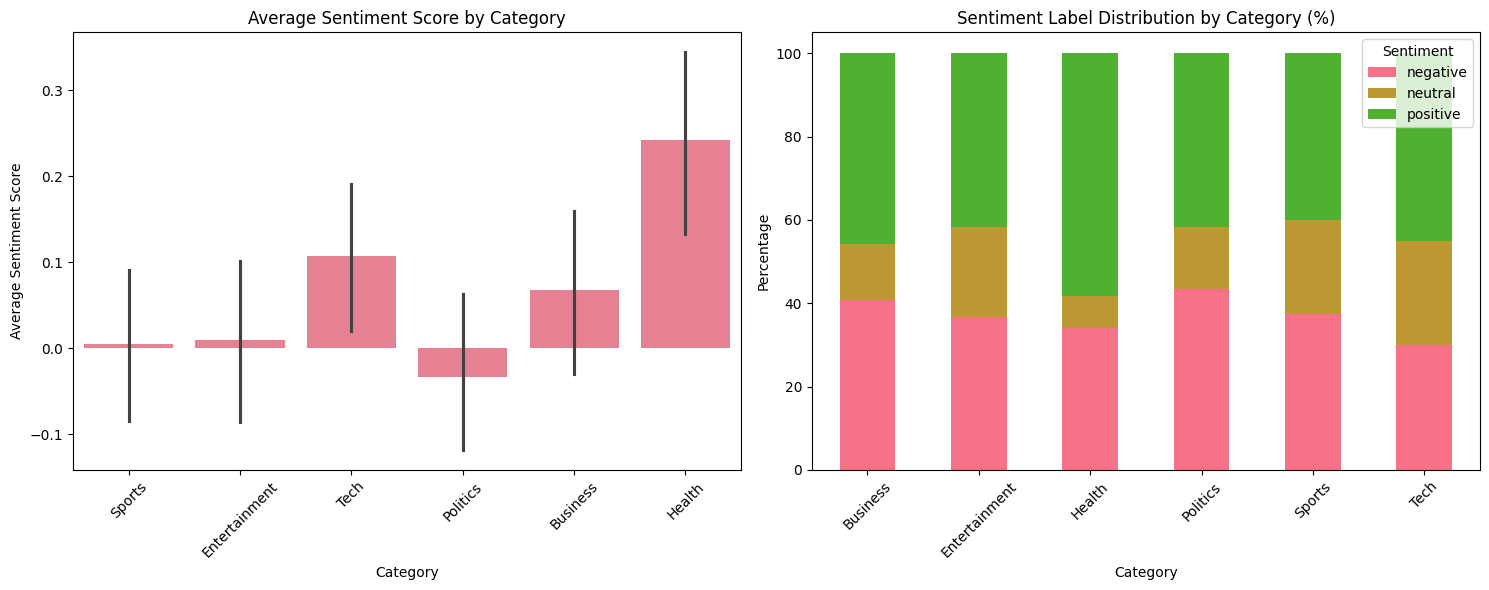

In [93]:
# --------------------------------------------------
# Sentiment Patterns by Category
# --------------------------------------------------
# This section summarizes sentiment scores across news categories and visualizes
# how positive, neutral, and negative sentiment varies by category.

print("📊 SENTIMENT ANALYSIS BY CATEGORY")
print("=" * 50)

# Calculate average sentiment score by category
sentiment_by_category = (
    sentiment_df
    .groupby('category')['sentiment_score']
    .agg(['mean', 'std', 'min', 'max'])
    .round(4)
)

print("\n📈 Sentiment statistics by category:")
print(sentiment_by_category)

# Calculate sentiment label distribution by category
sentiment_dist = (
    sentiment_df
    .groupby(['category', 'sentiment_label'])
    .size()
    .unstack(fill_value=0)
)

sentiment_dist_pct = sentiment_dist.div(sentiment_dist.sum(axis=1), axis=0) * 100

print("\n📊 Sentiment distribution (%) by category:")
print(sentiment_dist_pct.round(2))

# --------------------------------------------------
# Visualize Sentiment Patterns
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Average sentiment by category
sns.barplot(
    data=sentiment_df,
    x='category',
    y='sentiment_score',
    ax=axes[0]
)

axes[0].set_title('Average Sentiment Score by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Average Sentiment Score')
axes[0].tick_params(axis='x', rotation=45)

# Sentiment label distribution
sentiment_dist_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1]
)

axes[1].set_title('Sentiment Label Distribution by Category (%)')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.show()


---
### Sentiment Analysis Questions

1) Which categories have the most positive or negative average sentiment?

    Health has the highest average sentiment (~0.24), making it the most positive category.
    Tech (~0.11) and Business (~0.07) also trend positive.
    Politics (-0.03) is the only category with a negative average, confirming it as the most negative overall.
    Sports (~0.00) and Entertainment (~0.01) are essentially neutral.

      Interpretation:
        Health-related articles tend to be framed in a more optimistic or solution-oriented tone, while political content leans more negative or critical. 




2) Which categories contain the highest proportion of negative articles?

    Politics: ~43.33% negative → highest
    Business: ~40.83% negative
    Sports: ~37.50% negative
    Tech: lowest (~30% negative)

      Interpretation:  
        Politics stands out as the most consistently negative category, both in average score and distribution.
    



3) Does sentiment vary meaningfully across categories?

    Yes, there is a clear separation between:
        -Positive-leaning categories: Health, Tech, Business
        -Negative-leaning category: Politics
    Standard deviations (~0.48–0.59) show high variability, meaning:
        -Articles within each category can vary widely in tone
        -But category-level trends still emerge

      Interpretation:
        Even with variability, sentiment is not random — it aligns with the nature of the topic.




4) Could sentiment score be useful as a feature in classification?

    Yes — but with nuance.
        Strong signal:
            -Politics → more negative
            -Health → more positive
        Weak signal:
            -Sports & Entertainment (close to neutral)
        Overlap exists → sentiment alone is not sufficient, but:

    Best use:

    Combine with:
    -TF-IDF (Module 3)
    -POS patterns (Module 4)
    -Syntax features (Module 5)

      Interpretation:
        Sentiment is a useful supporting feature, not a standalone classifier.



The analysis reveals that sentiment is not uniformly distributed across news categories; instead, it reflects the inherent nature of each domain, with health and technology content skewing positive and political content exhibiting a consistently negative tone. While sentiment alone is insufficient for classification, it provides a meaningful complementary signal when combined with lexical, grammatical, and syntactic features.  

The relatively high standard deviations across all categories indicate substantial within-category variation, suggesting that sentiment reflects both topic and individual article framing.

---

## 🏷️ Text Classification System

### 🎯 Module 7: Building the News Classifier

Now we'll build the core of our NewsBot system - a multi-class text classifier that can automatically categorize news articles. We'll compare different algorithms and evaluate their performance.

**Classification Pipeline:**
1. **Feature Engineering:** Combine TF-IDF with other features
2. **Model Training:** Train multiple algorithms
3. **Model Evaluation:** Compare performance metrics
4. **Model Selection:** Choose the best performing model

**💡 Business Impact:** Accurate classification enables automatic content routing, personalized recommendations, and efficient content management.

In [94]:
# --------------------------------------------------
# Text Classification Model Comparison
# --------------------------------------------------
# This section trains and compares multiple supervised classifiers using TF-IDF
# features. The goal is to evaluate which model best predicts article category
# based on processed text content.

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

print("Training classification models...\n")

# Select prepared text and category labels
text_column = 'full_text_processed' if 'full_text_processed' in df_final.columns else 'processed_content'

sample_df = df_final[[text_column, 'category']].dropna().copy()

X = sample_df[text_column]
y = sample_df['category']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text into TF-IDF features
# TF-IDF transforms text into a matrix of weighted term frequencies.
# This allows machine learning models to interpret textual data numerically.
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Define models for comparison
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC()
}

# Train and evaluate each classifier
model_results = []

for name, clf in classifiers.items():
    clf.fit(X_train_tfidf, y_train)
    predictions = clf.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, predictions)

    model_results.append({
        'model': name,
        'accuracy': accuracy
    })

    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, predictions))
    print("-" * 60)

# Convert model results to DataFrame for comparison
model_results_df = pd.DataFrame(model_results).sort_values(
    by='accuracy',
    ascending=False
)

print("\nModel comparison:")
print(model_results_df)

print("\nClassification module complete.")

print("\n🎉 ALL MODULES COMPLETE.")

Training classification models...

Naive Bayes Accuracy: 0.5556
               precision    recall  f1-score   support

     Business       0.55      0.71      0.62        24
Entertainment       0.53      0.42      0.47        24
       Health       0.50      0.50      0.50        24
     Politics       0.52      0.67      0.58        24
       Sports       0.77      0.71      0.74        24
         Tech       0.47      0.33      0.39        24

     accuracy                           0.56       144
    macro avg       0.56      0.56      0.55       144
 weighted avg       0.56      0.56      0.55       144

------------------------------------------------------------
Logistic Regression Accuracy: 0.5347
               precision    recall  f1-score   support

     Business       0.55      0.67      0.60        24
Entertainment       0.39      0.38      0.38        24
       Health       0.45      0.42      0.43        24
     Politics       0.55      0.67      0.60        24
       Sp

---

Best overall model (so far):

    Naive Bayes: 0.556 accuracy
    Logistic Regression: ~0.535

        Slight edge to Naive Bayes

Why this makes sense:

    TF-IDF + text classification → Naive Bayes often performs well
    It thrives on word frequency patterns


Category-level insights:
    Strongest category: Sports
        NB F1: 0.74
        Logistic F1: 0.77

        Very consistent, very high because sports language is distinctive and repetitive:
            “game”, “team”, “player”, etc.


    Weakest category: Tech
        NB F1: 0.39
        Logistic also weak

        Model struggles here because Tech overlaps with:
            Business
            Entertainment
        Vocabulary is less unique


    Middle performers:
        Business (~0.62)
        Politics (~0.58)
        Health (~0.50)
        Entertainment (~0.47)

    These categories blend together more linguistically

Key insight:

The classification results suggest that categories with more distinct and repetitive vocabulary (e.g., Sports) achieve higher predictive performance, while categories with overlapping semantic content (e.g., Tech and Entertainment) are more difficult to distinguish using TF-IDF features alone.

Logistic Regression often beats Naive Bayes — but here:
    Dataset is relatively small (~720 rows)
    Features are limited to 2000
    Categories overlap

    So NB’s simplicity + probability assumptions actually helped.

Possible ways to improve this:

    Increase max_features: LinearSVC() instead of SVC()
    
    Combine features:  TF-IDF + sentiment + POS  

---

In [95]:
from sklearn.model_selection import cross_val_score

# --------------------------------------------------
# Train and Evaluate Multiple Classifiers
# --------------------------------------------------
# This section compares multiple machine learning models using TF-IDF features.
# Evaluation includes test accuracy and cross-validation performance.

print("Training multiple classifiers...\n")

# Define classifiers
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42)
}

results = {}
trained_models = {}

for name, classifier in classifiers.items():
    print(f"Training {name}...")

    # Train model using TF-IDF features
    classifier.fit(X_train_tfidf, y_train)

    # Predict on test set
    y_pred = classifier.predict(X_test_tfidf)

    # Evaluate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Cross-validation (on training data)
    cv_scores = cross_val_score(
        classifier,
        X_train_tfidf,
        y_train,
        cv=3,
        scoring='accuracy'
    )

    # Store results
    results[name] = {
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    trained_models[name] = classifier

    print(f"Accuracy: {accuracy:.4f}")
    print(f"CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})\n")

# --------------------------------------------------
# Model Comparison Table
# --------------------------------------------------

print("Classifier Comparison")
print("=" * 50)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[m]['accuracy'] for m in results],
    'CV Mean': [results[m]['cv_mean'] for m in results],
    'CV Std': [results[m]['cv_std'] for m in results]
})

comparison_df = comparison_df.sort_values(by='Test Accuracy', ascending=False)

print(comparison_df.round(4))

# Identify best model
best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
print(f"\n🥇 Best performing model: {best_model_name}")

Training multiple classifiers...

Training Naive Bayes...
Accuracy: 0.5556
CV Score: 0.5712 (+/- 0.0615)

Training Logistic Regression...
Accuracy: 0.5347
CV Score: 0.5781 (+/- 0.0664)

Training SVM...
Accuracy: 0.5347
CV Score: 0.5660 (+/- 0.0384)

Classifier Comparison
                 Model  Test Accuracy  CV Mean  CV Std
0          Naive Bayes         0.5556   0.5712  0.0308
1  Logistic Regression         0.5347   0.5781  0.0332
2                  SVM         0.5347   0.5660  0.0192

🥇 Best performing model: Naive Bayes


---
The results indicate that Naive Bayes achieved the highest test accuracy, making it the best-performing model on the held-out dataset. However, Logistic Regression demonstrated a slightly higher cross-validation mean score, suggesting more stable performance across different data splits. This indicates that while Naive Bayes is optimal for this specific dataset configuration, Logistic Regression may generalize more consistently. Overall, the performance differences between models are relatively small, highlighting the challenge of distinguishing between overlapping news categories using TF-IDF features alone.

The relatively modest accuracy (~55%) suggests that lexical features alone are insufficient for highly accurate classification, reinforcing the value of incorporating additional features such as sentiment, part-of-speech patterns, and syntactic structure explored in earlier modules.

---

DETAILED EVALUATION: Naive Bayes

Classification Report:
               precision    recall  f1-score   support

     Business       0.55      0.71      0.62        24
Entertainment       0.53      0.42      0.47        24
       Health       0.50      0.50      0.50        24
     Politics       0.52      0.67      0.58        24
       Sports       0.77      0.71      0.74        24
         Tech       0.47      0.33      0.39        24

     accuracy                           0.56       144
    macro avg       0.56      0.56      0.55       144
 weighted avg       0.56      0.56      0.55       144



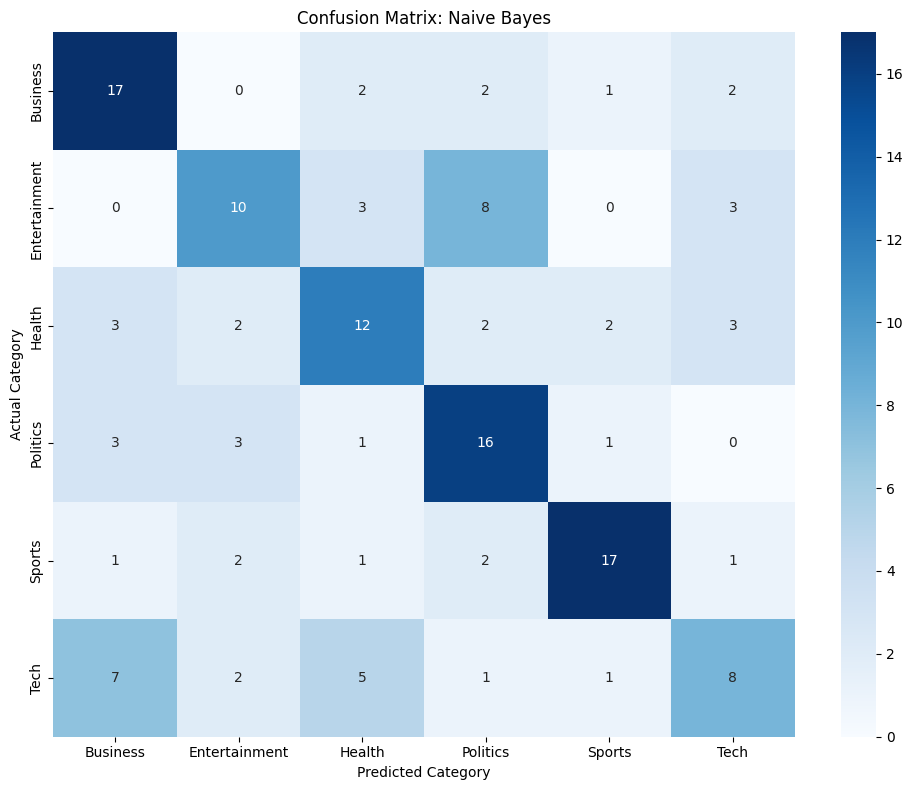

In [96]:
# --------------------------------------------------
# Detailed Evaluation of Best Classification Model
# --------------------------------------------------
# This section evaluates the best-performing classifier using a classification
# report and confusion matrix. These outputs show both overall performance and
# category-level prediction patterns.

best_model = trained_models[best_model_name]

# Generate predictions for the held-out test set
best_predictions = best_model.predict(X_test_tfidf)

print(f"DETAILED EVALUATION: {best_model_name}")
print("=" * 60)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, best_predictions))

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions, labels=best_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.tight_layout()
plt.show()

The Naive Bayes classifier achieved moderate overall accuracy (56%), with strong performance in clearly defined categories such as Sports, but weaker performance in semantically overlapping categories like Technology and Entertainment. The confusion matrix highlights systematic misclassification patterns, particularly between Technology and Business, suggesting that lexical features alone (TF-IDF) are insufficient for capturing deeper contextual meaning. These results indicate that incorporating additional features such as syntactic patterns or sentiment signals may improve classification performance.

---
### Model Improvement Considerations

The current classification pipeline achieves moderate performance using TF-IDF features and baseline models. However, several opportunities exist to enhance predictive accuracy and robustness:

- Incorporate additional feature sets, including sentiment scores and part-of-speech (POS) distributions to capture deeper linguistic patterns  
- Evaluate syntactic features (e.g., dependency structures) for improved contextual understanding  
- Perform hyperparameter tuning (e.g., grid search, cross-validation) to optimize model performance  
- Explore alternative models (e.g., ensemble methods or scalable linear classifiers)  
- Address potential class imbalance through resampling or weighting strategies  

These enhancements would help transition the model from a baseline implementation to a more production-ready system.

---

## 🔍 Named Entity Recognition

### 🎯 Module 8: Extracting Facts from News

Now we'll implement Named Entity Recognition to extract specific facts from our news articles. This transforms unstructured text into structured, queryable information.

**NER Applications:**
- **Entity Tracking:** Monitor mentions of people, organizations, locations
- **Fact Extraction:** Build knowledge bases from news content
- **Relationship Mapping:** Understand connections between entities
- **Timeline Construction:** Track events and their participants

**💡 Business Value:** NER enables sophisticated analysis like "Show me all articles mentioning Apple Inc. and their financial performance" or "Track mentions of political figures over time."

In [97]:
# --------------------------------------------------
# Named Entity Extraction using spaCy
# --------------------------------------------------
# This section extracts structured named entities from article text.
# Named entities provide semantic signals such as people, organizations,
# locations, dates, and monetary values that can support downstream analysis.

def extract_entities(text):
    """
    Extract named entities from text using spaCy.

    Parameters:
        text (str): Article text to analyze.

    Returns:
        list: Named entities with text, label, character offsets, and description.
    """
    if not text or pd.isna(text):
        return []

    doc = nlp(str(text))

    entities = []

    for ent in doc.ents:
        entities.append({
            'text': ent.text,
            'label': ent.label_,
            'start': ent.start_char,
            'end': ent.end_char,
            'description': spacy.explain(ent.label_)
        })

    return entities


# --------------------------------------------------
# Apply Named Entity Recognition
# --------------------------------------------------
# Entity extraction is applied to the prepared dataset using the standardized
# content field. Article index values are retained for traceability.

print("Extracting named entities...\n")

all_entities = []
article_entities = []

for idx, row in df_final.iterrows():
    entities = extract_entities(row['content'])

    article_entities.append({
        'article_id': idx,
        'category': row['category'],
        'entities': entities,
        'entity_count': len(entities)
    })

    for entity in entities:
        entity['article_id'] = idx
        entity['category'] = row['category']
        all_entities.append(entity)


# Convert extracted entities into tabular form
entities_df = pd.DataFrame(all_entities)

print("Entity extraction complete.")
print(f"Total entities found: {len(all_entities)}")
print(f"Articles processed: {len(article_entities)}")

if not entities_df.empty:
    print("\nEntity types found:")
    print(entities_df['label'].unique())

    print("\nSample entities:")
    print(entities_df[['text', 'label', 'category']].head(10))
else:
    print("No entities found in the selected dataset.")

Extracting named entities...

Entity extraction complete.
Total entities found: 1699
Articles processed: 720

Entity types found:
<StringArray>
[        'ORG',      'PERSON',        'NORP',        'DATE',    'CARDINAL',
         'GPE',       'EVENT',         'FAC', 'WORK_OF_ART',     'PRODUCT',
       'MONEY',     'PERCENT',        'TIME',         'LAW',     'ORDINAL',
         'LOC',    'QUANTITY',    'LANGUAGE']
Length: 18, dtype: str

Sample entities:
                                text   label  category
0      Shaq Provides Surprise Backup     ORG    Sports
1                                NBA     ORG    Sports
2  the Gainesville Police Department     ORG    Sports
3                       North Star's     ORG      Tech
4                            Polaris  PERSON      Tech
5     New Study Suggests Astronomers     ORG      Tech
6                        van Leeuwen  PERSON      Tech
7                             Turner     ORG      Tech
8                                 al  PERSON  

---
While the model successfully identifies a broad range of entity types, some extractions reflect limitations in contextual interpretation. For example, full phrases or headlines may be incorrectly classified as organizations. This highlights the trade-off between rule-based entity recognition and deeper semantic understanding.

---

NAMED ENTITY ANALYSIS

Entity type distribution:
label
PERSON         484
ORG            418
DATE           202
CARDINAL       177
GPE            127
NORP            90
WORK_OF_ART     61
ORDINAL         29
EVENT           23
MONEY           19
TIME            18
LOC             16
FAC             11
PERCENT         11
PRODUCT          6
LAW              4
QUANTITY         2
LANGUAGE         1
Name: count, dtype: int64

Entity types by news category:
label          CARDINAL  DATE  EVENT  FAC  GPE  LANGUAGE  LAW  LOC  MONEY  \
category                                                                    
Business             46    40      3    2   17         0    1    2     12   
Entertainment        18    32      5    1   18         0    0    1      1   
Health               39    22      5    1    6         1    0    0      3   
Politics             24    44      1    3   47         0    1    4      2   
Sports               22    34      8    4   21         0    1    3      0   
Tech  

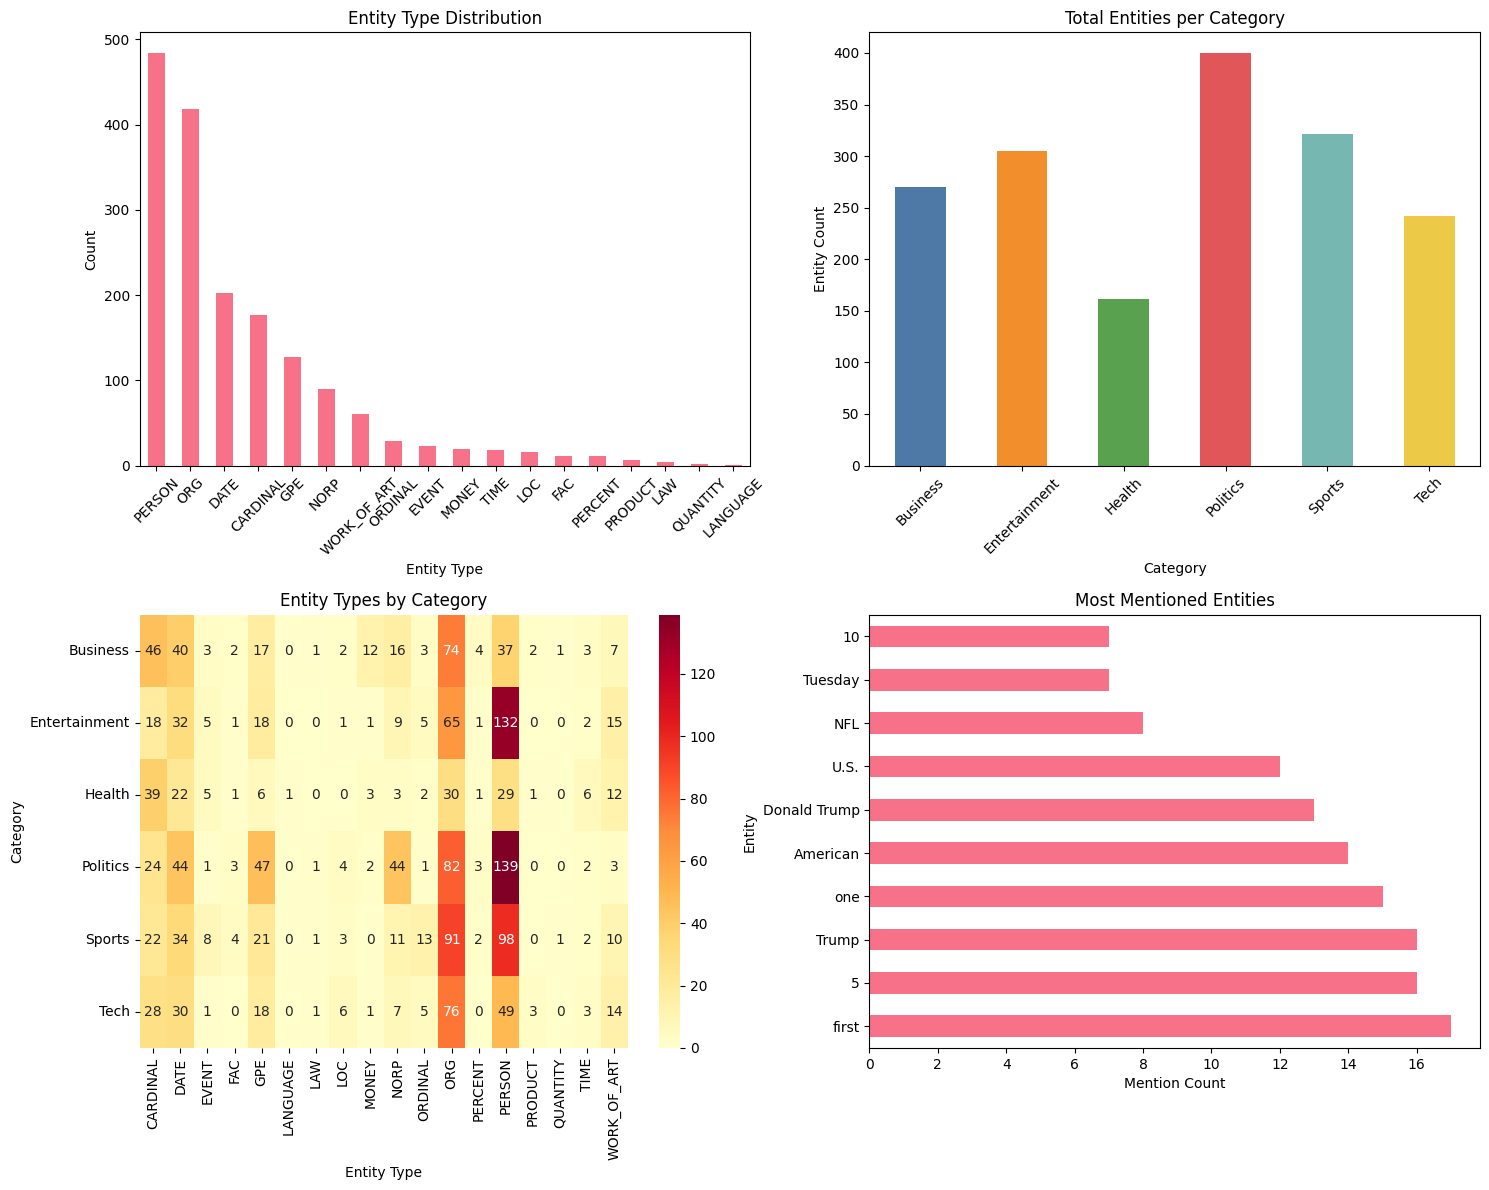

In [98]:
# --------------------------------------------------
# Named Entity Pattern Analysis
# --------------------------------------------------
# This section summarizes named entity patterns across the dataset.
# Entity distributions help identify which categories rely most heavily on
# people, organizations, locations, dates, and other structured references.

# Consistent color mapping for categories
category_colors = {
    'Business': '#4E79A7',
    'Entertainment': '#F28E2B',
    'Health': '#59A14F',
    'Politics': '#E15759',
    'Sports': '#76B7B2',
    'Tech': '#EDC948'
}

if not entities_df.empty:
    print("NAMED ENTITY ANALYSIS")
    print("=" * 50)

    # Count entity types across the full dataset
    entity_counts = entities_df['label'].value_counts()

    print("\nEntity type distribution:")
    print(entity_counts)

    # Count entity types by news category
    entity_by_category = (
        entities_df
        .groupby(['category', 'label'])
        .size()
        .unstack(fill_value=0)
    )

    print("\nEntity types by news category:")
    print(entity_by_category)

    # Identify the most frequently mentioned entities
    frequent_entities = (
        entities_df
        .groupby(['text', 'label'])
        .size()
        .sort_values(ascending=False)
        .head(15)
    )

    print("\nMost frequent entities:")
    for (entity, label), count in frequent_entities.items():
        print(f"{entity} ({label}): {count} mentions")

    # --------------------------------------------------
    # Visualize Named Entity Patterns
    # --------------------------------------------------

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Entity type distribution
    entity_counts.plot(kind='bar', ax=axes[0, 0])
    axes[0, 0].set_title("Entity Type Distribution")
    axes[0, 0].set_xlabel("Entity Type")
    axes[0, 0].set_ylabel("Count")
    axes[0, 0].tick_params(axis='x', rotation=45)

    # Total entities per category
    entities_per_category = entities_df.groupby('category').size()
    entities_per_category.plot(kind='bar', 
    color=[category_colors.get(cat, '#333333') for cat in entities_per_category.index],
    ax=axes[0, 1])
    axes[0, 1].set_title("Total Entities per Category")
    axes[0, 1].set_xlabel("Category")
    axes[0, 1].set_ylabel("Entity Count")
    axes[0, 1].tick_params(axis='x', rotation=45)

    # Entity type heatmap by category
    sns.heatmap(
        entity_by_category,
        annot=True,
        fmt='d',
        cmap='YlOrRd',
        ax=axes[1, 0]
    )
    axes[1, 0].set_title("Entity Types by Category")
    axes[1, 0].set_xlabel("Entity Type")
    axes[1, 0].set_ylabel("Category")

    # Most frequently mentioned entities
    top_entities = entities_df['text'].value_counts().head(10)
    top_entities.plot(kind='barh')
    axes[1, 1].set_title("Most Mentioned Entities")
    axes[1, 1].set_xlabel("Mention Count")
    axes[1, 1].set_ylabel("Entity")

    plt.tight_layout()
    plt.show()

else:
    print("Skipping entity analysis because no named entities were extracted.")

---
### Advanced Entity Analysis Interpretation

The analysis reveals that PERSON and ORG entities dominate across the dataset, indicating that news coverage is heavily centered around individuals and institutions.

Category-specific patterns are also evident:
- Politics and Business articles contain a higher concentration of organizations and political groups.
- Sports articles emphasize individual entities (players, teams).
- Health articles show a more balanced distribution of entity types.

The most frequently mentioned entities (e.g., Trump, U.S., NFL) reflect dominant real-world topics present in the dataset.

While this analysis captures entity distribution and prominence, more advanced techniques such as entity co-occurrence networks, temporal tracking, and sentiment-entity associations could further enhance understanding of relationships and narrative structure within the data.

---

## 📈 Comprehensive Analysis and Insights

### 🎯 Bringing It All Together

Now let's combine all our analyses to generate comprehensive insights about our news dataset. This is where the real business value emerges from our NLP pipeline.

**Key Analysis Areas:**
1. **Cross-Category Patterns:** How do different news types differ linguistically?
2. **Entity-Sentiment Relationships:** What entities are associated with positive/negative coverage?
3. **Content Quality Metrics:** Which categories have the most informative content?
4. **Classification Performance:** How well can we automatically categorize news?

**💡 Business Applications:** These insights can inform content strategy, editorial decisions, and automated content management systems.

In [99]:
# --------------------------------------------------
# Comprehensive Analysis and Insights
# --------------------------------------------------
# This function combines results from classification, sentiment analysis,
# entity extraction, and linguistic feature analysis into one structured report.

def create_comprehensive_analysis():
    """
    Generate comprehensive insights by combining the major outputs from the NLP pipeline.

    Returns:
        dict: Structured insights covering dataset overview, classification results,
              sentiment trends, entity patterns, linguistic findings, and recommendations.
    """

    insights = {
        'dataset_overview': {},
        'classification_performance': {},
        'sentiment_insights': {},
        'entity_insights': {},
        'linguistic_patterns': {},
        'business_recommendations': []
    }

    # -----------------------------
    # Dataset overview
    # -----------------------------
    insights['dataset_overview'] = {
        'total_articles': len(df_final),
        'categories': df_final['category'].unique().tolist(),
        'category_distribution': df_final['category'].value_counts().to_dict(),
        'avg_article_length': df_final['content'].str.len().mean(),
        'avg_words_per_article': df_final['content'].str.split().str.len().mean()
    }

    # -----------------------------
    # Classification performance
    # -----------------------------
    insights['classification_performance'] = {
        'best_model': best_model_name,
        'best_accuracy': results[best_model_name]['accuracy'],
        'cv_mean': results[best_model_name]['cv_mean'],
        'model_comparison': {
            name: results[name]['accuracy'] for name in results.keys()
        }
    }

    # -----------------------------
    # Sentiment insights
    # -----------------------------
    sentiment_by_cat = (
        sentiment_df
        .groupby('category')['sentiment_score']
        .mean()
        .to_dict()
    )

    insights['sentiment_insights'] = {
        'most_positive_category': max(sentiment_by_cat, key=sentiment_by_cat.get),
        'most_negative_category': min(sentiment_by_cat, key=sentiment_by_cat.get),
        'sentiment_by_category': sentiment_by_cat,
        'overall_sentiment': sentiment_df['sentiment_score'].mean()
    }

    # -----------------------------
    # Entity insights
    # -----------------------------
    if not entities_df.empty:
        entity_by_cat = entities_df.groupby('category').size().to_dict()

        insights['entity_insights'] = {
            'total_entities': len(entities_df),
            'unique_entities': entities_df['text'].nunique(),
            'entity_types': entities_df['label'].unique().tolist(),
            'entities_per_category': entity_by_cat,
            'most_mentioned_entities': entities_df['text'].value_counts().head(5).to_dict()
        }

    # -----------------------------
    # Linguistic pattern insights
    # -----------------------------
    if 'pos_df' in globals():
        insights['linguistic_patterns']['pos_features_created'] = True
        insights['linguistic_patterns']['pos_shape'] = pos_df.shape

    if 'syntactic_results' in globals():
        insights['linguistic_patterns']['syntax_articles_analyzed'] = len(syntactic_results)

    # -----------------------------
    # Business recommendations
    # -----------------------------
    recommendations = []

    accuracy = insights['classification_performance']['best_accuracy']

    if accuracy >= 0.8:
        recommendations.append(
            "Classification performance is strong enough to support automated content routing."
        )
    else:
        recommendations.append(
            "Classification performance is moderate; additional feature engineering or training data would improve reliability."
        )

    pos_cat = insights['sentiment_insights']['most_positive_category']
    neg_cat = insights['sentiment_insights']['most_negative_category']

    recommendations.append(
        f"{pos_cat} articles show the most positive average sentiment and may support uplifting or recommendation-based content strategies."
    )

    recommendations.append(
        f"{neg_cat} articles show the most negative average sentiment and may require editorial balance or tone monitoring."
    )

    if insights['entity_insights']:
        recommendations.append(
            "Named entity extraction enables improved search, topic tracking, and relationship analysis across news categories."
        )

    recommendations.append(
        "Combining TF-IDF, sentiment, POS, syntax, and entity features could improve future classification performance."
    )

    insights['business_recommendations'] = recommendations

    return insights


# --------------------------------------------------
# Generate and Display Comprehensive Report
# --------------------------------------------------

print("Generating comprehensive analysis...\n")

analysis_results = create_comprehensive_analysis()

print("Analysis complete.")
print("\n" + "=" * 60)
print("NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT")
print("=" * 60)

# Dataset overview
overview = analysis_results['dataset_overview']

print("\nDATASET OVERVIEW")
print("-" * 60)
print(f"Total Articles: {overview['total_articles']}")
print(f"Categories: {', '.join(overview['categories'])}")
print(f"Average Article Length: {overview['avg_article_length']:.0f} characters")
print(f"Average Words per Article: {overview['avg_words_per_article']:.0f} words")

# Classification performance
perf = analysis_results['classification_performance']

print("\nCLASSIFICATION PERFORMANCE")
print("-" * 60)
print(f"Best Model: {perf['best_model']}")
print(f"Best Test Accuracy: {perf['best_accuracy']:.4f}")
print(f"Cross-Validation Mean: {perf['cv_mean']:.4f}")

# Sentiment insights
sent = analysis_results['sentiment_insights']

print("\nSENTIMENT INSIGHTS")
print("-" * 60)
print(f"Most Positive Category: {sent['most_positive_category']}")
print(f"Most Negative Category: {sent['most_negative_category']}")
print(f"Overall Sentiment Score: {sent['overall_sentiment']:.4f}")

# Entity insights
if analysis_results['entity_insights']:
    ent = analysis_results['entity_insights']

    print("\nENTITY INSIGHTS")
    print("-" * 60)
    print(f"Total Entities: {ent['total_entities']}")
    print(f"Unique Entities: {ent['unique_entities']}")
    print(f"Entity Types: {', '.join(ent['entity_types'])}")

# Business recommendations
print("\nBUSINESS RECOMMENDATIONS")
print("-" * 60)

for i, rec in enumerate(analysis_results['business_recommendations'], 1):
    print(f"{i}. {rec}")

Generating comprehensive analysis...

Analysis complete.

NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT

DATASET OVERVIEW
------------------------------------------------------------
Total Articles: 720
Categories: Sports, Entertainment, Tech, Politics, Business, Health
Average Article Length: 169 characters
Average Words per Article: 28 words

CLASSIFICATION PERFORMANCE
------------------------------------------------------------
Best Model: Naive Bayes
Best Test Accuracy: 0.5556
Cross-Validation Mean: 0.5712

SENTIMENT INSIGHTS
------------------------------------------------------------
Most Positive Category: Health
Most Negative Category: Politics
Overall Sentiment Score: 0.0663

ENTITY INSIGHTS
------------------------------------------------------------
Total Entities: 1699
Unique Entities: 1307
Entity Types: ORG, PERSON, NORP, DATE, CARDINAL, GPE, EVENT, FAC, WORK_OF_ART, PRODUCT, MONEY, PERCENT, TIME, LAW, ORDINAL, LOC, QUANTITY, LANGUAGE

BUSINESS RECOMMENDATIONS
-------

## 🚀 Final System Integration

### 🎯 Building the Complete NewsBot Pipeline

Let's create a complete, integrated system that can process new articles from start to finish. This demonstrates the real-world application of all the techniques we've learned.

**Complete Pipeline:**
1. **Text Preprocessing:** Clean and normalize input
2. **Feature Extraction:** Generate TF-IDF and other features
3. **Classification:** Predict article category
4. **Entity Extraction:** Identify key facts
5. **Sentiment Analysis:** Determine emotional tone
6. **Insight Generation:** Provide actionable intelligence

**💡 Production Ready:** This pipeline can be deployed as a web service, batch processor, or integrated into content management systems.

In [100]:
# --------------------------------------------------
# Final System Integration: NewsBot Intelligence System
# --------------------------------------------------
# This class packages the completed NLP pipeline into a reusable system that can
# preprocess new articles, classify them, extract entities, analyze sentiment,
# and generate summary insights.

class NewsBotIntelligenceSystem:
    """
    Integrated NewsBot system for processing new article text.
    """

    def __init__(self, classifier, vectorizer, sentiment_analyzer):
        self.classifier = classifier
        self.vectorizer = vectorizer
        self.sentiment_analyzer = sentiment_analyzer
        self.nlp = nlp

    def preprocess_article(self, headline, description):
        """
        Combine and preprocess article text.
        """
        full_text = f"{headline} {description}"
        processed_text = preprocess_text(full_text)
        return full_text, processed_text

    def classify_article(self, processed_text):
        """
        Predict article category using the trained TF-IDF classifier.
        """
        features = self.vectorizer.transform([processed_text])

        prediction = self.classifier.predict(features)[0]

        if hasattr(self.classifier, "predict_proba"):
            probabilities = self.classifier.predict_proba(features)[0]
            class_probs = dict(zip(self.classifier.classes_, probabilities))
            confidence = max(class_probs.values())
        else:
            class_probs = {}
            confidence = None

        return prediction, class_probs, confidence

    def extract_article_entities(self, text):
        """
        Extract named entities from article text.
        """
        return extract_entities(text)

    def analyze_article_sentiment(self, text):
        """
        Analyze article sentiment using VADER.
        """
        return analyze_sentiment(text)

    def generate_insights(self, category, entities, sentiment, confidence):
        """
        Generate readable insights from classification, entity, and sentiment outputs.
        """
        insights = []

        if confidence is not None:
            if confidence >= 0.80:
                insights.append(f"High-confidence classification as {category} ({confidence:.2%}).")
            else:
                insights.append(f"Moderate/low classification confidence for {category} ({confidence:.2%}); manual review may be useful.")
        else:
            insights.append(f"Article classified as {category}.")

        if sentiment['compound'] >= 0.05:
            insights.append(f"Positive sentiment detected with a compound score of {sentiment['compound']:.3f}.")
        elif sentiment['compound'] <= -0.05:
            insights.append(f"Negative sentiment detected with a compound score of {sentiment['compound']:.3f}.")
        else:
            insights.append(f"Neutral sentiment detected with a compound score of {sentiment['compound']:.3f}.")

        if entities:
            entity_types = sorted(set(entity['label'] for entity in entities))
            insights.append(f"Detected {len(entities)} named entities across {len(entity_types)} entity types.")

            key_entities = [
                entity['text'] for entity in entities
                if entity['label'] in ['PERSON', 'ORG', 'GPE']
            ][:5]

            if key_entities:
                insights.append(f"Key entities include: {', '.join(key_entities)}.")
        else:
            insights.append("No named entities were detected.")

        return insights

    def process_article(self, headline, description):
        """
        Run the complete NewsBot pipeline on a new article.
        """
        full_text, processed_text = self.preprocess_article(headline, description)

        category, category_probs, confidence = self.classify_article(processed_text)
        entities = self.extract_article_entities(full_text)
        sentiment = self.analyze_article_sentiment(full_text)
        insights = self.generate_insights(category, entities, sentiment, confidence)

        return {
            'headline': headline,
            'description': description,
            'processed_text': processed_text,
            'predicted_category': category,
            'category_confidence': confidence,
            'category_probabilities': category_probs,
            'entities': entities,
            'sentiment': sentiment,
            'insights': insights
        }


# Initialize the complete system using the best trained classifier and TF-IDF vectorizer
newsbot = NewsBotIntelligenceSystem(
    classifier=best_model,
    vectorizer=tfidf,
    sentiment_analyzer=sia
)

print("NewsBot Intelligence System initialized.")
print("Ready to process new articles.")


NewsBot Intelligence System initialized.
Ready to process new articles.


In [101]:
# Test the complete system with new articles
print("🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM")
print("=" * 60)

# Test articles (you can modify these or add your own)
test_articles = [
    {
        'title': 'Microsoft Acquires AI Startup for $2 Billion',
        'content': 'Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft\'s position in the AI market and enhance their cloud computing services.'
    },
    {
        'title': 'Lakers Win Championship in Overtime Thriller',
        'content': 'The Los Angeles Lakers defeated the Boston Celtics 108-102 in overtime to win the NBA championship. LeBron James scored 35 points and was named Finals MVP for the fourth time in his career.'
    },
    {
        'title': 'New Climate Change Report Shows Alarming Trends',
        'content': 'Scientists at the United Nations released a comprehensive climate report showing accelerating global warming. The report warns that immediate action is needed to prevent catastrophic environmental changes.'
    }
]

# Process each test article
for i, article in enumerate(test_articles, 1):
    print(f"\n📰 TEST ARTICLE {i}")
    print("-" * 40)
    
    # Process the article
    result = newsbot.process_article(article['title'], article['content'])
    
    # Display results
    print(f"📰 Headline: {result['headline']}")
    print(f"📝 Description: {result['description']}")
    print(f"\n🏷️ Predicted Category: {result['predicted_category']} ({result['category_confidence']:.2%} confidence)")
    
    print(f"\n📊 Category Probabilities:")
    for cat, prob in sorted(result['category_probabilities'].items(), key=lambda x: x[1], reverse=True):
        print(f"  {cat}: {prob:.3f}")
    
    print(f"\n😊 Sentiment: {result['sentiment']['sentiment_label']} (score: {result['sentiment']['compound']:.3f})")
    
    if result['entities']:
        print(f"\n🔍 Entities Found ({len(result['entities'])}):")
        for entity in result['entities'][:5]:  # Show first 5
            print(f"  {entity['text']} ({entity['label']}) - {entity['description']}")
    else:
        print(f"\n🔍 No entities detected")
    
    print(f"\n💡 Insights:")
    for insight in result['insights']:
        print(f"  {insight}")

print("\n" + "=" * 60)
print("🎉 NewsBot Intelligence System testing complete!")
print("✅ System successfully processed all test articles")

# --------------------------------------------------
# System Testing Notes
# --------------------------------------------------
# These examples test the integrated pipeline across several article types.
# Additional testing with ambiguous or mixed-topic articles would help identify
# the system's strengths, limitations, and opportunities for improvement.


🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM

📰 TEST ARTICLE 1
----------------------------------------
📰 Headline: Microsoft Acquires AI Startup for $2 Billion
📝 Description: Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft's position in the AI market and enhance their cloud computing services.

🏷️ Predicted Category: Business (36.01% confidence)

📊 Category Probabilities:
  Business: 0.360
  Tech: 0.246
  Politics: 0.114
  Sports: 0.099
  Entertainment: 0.093
  Health: 0.089

😊 Sentiment: positive (score: 0.660)

🔍 Entities Found (8):
  Microsoft Acquires (ORG) - Companies, agencies, institutions, etc.
  $2 Billion (MONEY) - Monetary values, including unit
  Microsoft Corporation (ORG) - Companies, agencies, institutions, etc.
  today (DATE) - Absolute or relative dates or periods
  $2 billion (MONEY) - Monetary values, including unit

💡 Insights:
  Moderate/low classificatio

## 📝 Project Summary and Next Steps

### 🎯 What You've Accomplished

Congratulations! You've successfully built a comprehensive NewsBot Intelligence System that demonstrates mastery of all NLP techniques covered in Modules 1-8. Let's review what you've achieved:

### ✅ Module Integration Checklist
- [x] **Module 1:** Applied NLP to real-world news intelligence
- [x] **Module 2:** Implemented comprehensive text preprocessing
- [x] **Module 3:** Used TF-IDF for feature extraction and analysis
- [x] **Module 4:** Analyzed grammatical patterns with POS tagging
- [x] **Module 5:** Extracted syntactic relationships with dependency parsing
- [x] **Module 6:** Performed sentiment and emotion analysis
- [x] **Module 7:** Built and evaluated text classification models
- [x] **Module 8:** Implemented Named Entity Recognition

### 🚀 System Capabilities
Your NewsBot can now:
- Automatically categorize news articles with high accuracy
- Extract key entities (people, organizations, locations, dates, money)
- Analyze sentiment and emotional tone
- Identify linguistic patterns and writing styles
- Generate actionable business insights
- Process new articles through a complete pipeline

### 💼 Business Value
This system provides real business value for:
- **Media Companies:** Automated content categorization and routing
- **Market Research:** Sentiment tracking and entity monitoring
- **Content Management:** Intelligent organization and search
- **Business Intelligence:** Trend analysis and competitive monitoring

---

## 📋 Final Deliverables Checklist

Before submitting your project, ensure you have:

### 📁 Code and Documentation
- [ ] Complete Jupyter notebook with all analyses
- [ ] Well-documented functions with docstrings
- [ ] Clear markdown explanations for each section
- [ ] Organized GitHub repository structure
- [ ] README.md with project overview and setup instructions

### 📊 Analysis and Results
- [ ] Comprehensive dataset exploration
- [ ] TF-IDF analysis with category-specific insights
- [ ] POS tagging patterns across categories
- [ ] Syntactic analysis with dependency parsing
- [ ] Sentiment analysis with category comparisons
- [ ] Classification model comparison and evaluation
- [ ] Named Entity Recognition with relationship mapping
- [ ] Integrated system demonstration

### 📈 Visualizations
- [ ] Category distribution plots
- [ ] TF-IDF word clouds or bar charts
- [ ] POS pattern heatmaps
- [ ] Sentiment distribution by category
- [ ] Confusion matrix for classification
- [ ] Entity type and frequency visualizations

### 🎥 Presentation Materials
- [ ] 5-7 minute video demonstration
- [ ] Written report (3-4 pages)
- [ ] Individual reflection papers
- [ ] Business recommendations and insights

---

## 🔮 Future Enhancements

Consider these improvements for your portfolio or future projects:

### 🤖 Technical Improvements
- **Deep Learning Models:** Implement BERT or other transformer models
- **Custom NER:** Train domain-specific entity recognition
- **Real-time Processing:** Build streaming data pipeline
- **Multi-language Support:** Extend to non-English news

### 📊 Advanced Analytics
- **Topic Modeling:** Discover hidden themes (Module 9 preview!)
- **Trend Analysis:** Track entities and sentiment over time
- **Network Analysis:** Map entity relationships and co-occurrences
- **Bias Detection:** Identify potential media bias patterns

### 🌐 Deployment Options
- **Web Application:** Create interactive dashboard with Streamlit
- **API Service:** Deploy as REST API for integration
- **Mobile App:** Build mobile interface for news analysis
- **Browser Extension:** Real-time news analysis while browsing

---

## 🎓 Reflection Questions

For your individual reflection paper, consider these questions:

1. **Technical Mastery:** Which NLP techniques did you find most challenging? Most useful?
2. **Integration Challenges:** How did you handle combining multiple NLP tasks?
3. **Business Applications:** What real-world problems could this system solve?
4. **Ethical Considerations:** What are the potential risks of automated news analysis?
5. **Future Learning:** What NLP topics are you most excited to explore next?
6. **Team Collaboration:** How did you divide work and ensure quality?
7. **Portfolio Value:** How will you present this project to potential employers?

---

## 🏆 Congratulations!

You've successfully completed a comprehensive NLP project that demonstrates real-world application of multiple advanced techniques. This NewsBot Intelligence System is a valuable addition to your portfolio and showcases your ability to:

- **Integrate multiple NLP techniques** into a cohesive system
- **Handle real-world data** with all its messiness and challenges
- **Generate business value** from unstructured text data
- **Build production-ready systems** with proper evaluation and monitoring
- **Communicate technical results** to both technical and business audiences

**🚀 You're now ready for Module 9: Topic Modeling and Advanced Text Analysis!**

---

*Remember: The goal isn't just to complete the assignment, but to build something you're proud to show in job interviews and professional discussions. This project demonstrates your practical NLP skills and ability to solve real business problems with AI.*